<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
    Time Series Modeling Pipeline for CO₂ Emission Forecasting
</center></p></h1>

<center> <img src="https://cienciadedatos.net/images/forecasting_multi-step_en.gif" width="500" height="300"> </center>

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">1️⃣ Step 1 | About Dataset </font><br>
 <br>   
<br>

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">
  <h2 style="color:blue;">Time Series Modeling for CO2 Emissions</h2>

  <h3>1. Introduction</h3>
  <p>
    Time series are data points collected at constant time intervals. They may have trends, seasonality, or noise. Modeling time series allows extraction of patterns and prediction of future values. This notebook uses monthly CO2 emissions data from electricity generation (2013-2025) from the 
    <a href="https://www.eia.gov/electricity/data.php#elecenv" target="_blank">dataset</a>.
  </p>

  <h3>2. Dataset Overview</h3>
  <ul>
    <li><b>Source:</b> Energy Information Administration, Jason McNeill</li>
    <li><b>Frequency:</b> Monthly</li>
    <li><b>Period:</b> Jan 2013 – Jul 2025</li>
    <li><b>Features:</b> CO2 emissions by energy source</li>
  </ul>

  <h3>3. Modeling Approaches</h3>

  

  <h4 style="color:blue;">3.4 LSTM (Long Short-Term Memory)</h4>
  <p>Deep learning RNN capable of long-term dependencies. Uses memory cells and gates. Sliding-window supervised learning. Excels in complex nonlinear patterns.</p>

  
  <h3>4. Time Series Analysis Workflow</h3>
  <ol>
    <li>Load dataset and visualize trends</li>
    <li>Test stationarity (ADF test, rolling statistics)</li>
    <li>Transform series if needed (differencing, log transform)</li>
    <li>Split into train/test</li>
    <li>Model selection:
      <ul>
    </li>
    <li>Train models, perform hyperparameter optimization (grid search, cross-validation)</li>
    <li>Evaluate forecasts (MAE, RMSE)</li>
    <li>Visualize predictions with confidence intervals</li>
    <li>Forecast future CO2 emissions (e.g., next 10 years)</li>
  </ol>

  <h3>5. Key Notes</h3>
  <ul>
    <li>Data preprocessing is crucial (stationarity, scaling, missing values)</li>
    <li>Seasonality and trends must be accounted for</li>
    <li>Deep learning models require larger datasets and computational resources</li>
  </ul>
</div>


In [ ]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.subplots as sp


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential


from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

import warnings 
warnings.filterwarnings('ignore')

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    Data Loading
</center></p></h1>

In [ ]:
df = pd.read_csv('MER_T12_06.csv')
df.head()

,MSN,Unnamed: 1,YYYYMM,Value,Column_Order,Description,Unit
0,CLEIEUS,197301,201301,72.076,1,Coal Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide
1,NNEIEUS,197301,201301,12.175,2,Natural Gas Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide
2,DKEIEUS,197301,201301,2.375,3,"Distillate Fuel, Including Kerosene-Type Jet F...",Million Metric Tons of Carbon Dioxide
3,PCEIEUS,197301,201301,0.128,4,Petroleum Coke Electric Power Sector CO2 Emiss...,Million Metric Tons of Carbon Dioxide
4,RFEIEUS,197301,201301,24.867,5,Residual Fuel Oil Electric Power Sector CO2 Em...,Million Metric Tons of Carbon Dioxide


In [33]:
df['datetime'] = pd.to_datetime(df['YYYYMM'], format='%Y%m', errors='coerce')  
df.drop(columns=['YYYYMM', "Unnamed: 1"], inplace=True)
df.head()

,MSN,Value,Column_Order,Description,Unit,datetime
0,CLEIEUS,72.076,1,Coal Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide,2013-01-01
1,NNEIEUS,12.175,2,Natural Gas Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide,2013-01-01
2,DKEIEUS,2.375,3,"Distillate Fuel, Including Kerosene-Type Jet F...",Million Metric Tons of Carbon Dioxide,2013-01-01
3,PCEIEUS,0.128,4,Petroleum Coke Electric Power Sector CO2 Emiss...,Million Metric Tons of Carbon Dioxide,2013-01-01
4,RFEIEUS,24.867,5,Residual Fuel Oil Electric Power Sector CO2 Em...,Million Metric Tons of Carbon Dioxide,2013-01-01


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Basic Understanding Data  
</center></p></h1>

### Exploratory Data Analysis

In [44]:

def check_df(df, name="Dataset", head=5):
    print("\n" + "="*60)
    print(f"📊 DATASET OVERVIEW: {name}")
    print("="*60)

    # 1. Shape
    print("\n📌 SHAPE")
    print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

    # 2. Data Types (per column)
    print("\n📌 DATA TYPES (PER COLUMN)")
    print(df.dtypes)

    # 3. Data Type Summary
    print("\n📌 DATA TYPE SUMMARY")
    print(df.dtypes.value_counts())

    # 4. Info
    print("\n📌 INFO")
    df.info()

    # 5. Head
    print("\n📌 HEAD")
    display(df.head(head))

    # 6. Tail
    print("\n📌 TAIL")
    display(df.tail(head))

    # 7. Missing Values
    print("\n📌 MISSING VALUES")
    print(df.isnull().sum())

    # 8. Duplicate Rows
    print("\n📌 DUPLICATE ROWS")
    print(f"Number of duplicate rows: {df.duplicated().sum()}")

    # 9. Descriptive Statistics (numeric only)
    print("\n📌 DESCRIPTIVE STATISTICS (NUMERIC)")
    display(df.describe())


In [5]:
check_df(df, "CO2 Data")


📊 DATASET OVERVIEW: CO2 Data

📌 SHAPE
Rows: 1364 | Columns: 6

📌 DATA TYPES (PER COLUMN)
MSN                     object
Value                   object
Column_Order             int64
Description             object
Unit                    object
datetime        datetime64[ns]
dtype: object

📌 DATA TYPE SUMMARY
object            4
int64             1
datetime64[ns]    1
Name: count, dtype: int64

📌 INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1364 entries, 0 to 1363
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   MSN           1364 non-null   object        
 1   Value         1364 non-null   object        
 2   Column_Order  1364 non-null   int64         
 3   Description   1364 non-null   object        
 4   Unit          1364 non-null   object        
 5   datetime      1303 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 64.1+ KB

📌 HEAD


,MSN,Value,Column_Order,Description,Unit,datetime
0,CLEIEUS,72.076,1,Coal Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide,2013-01-01
1,CLEIEUS,64.442,1,Coal Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide,2013-02-01
2,CLEIEUS,64.084,1,Coal Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide,2013-03-01
3,CLEIEUS,60.842,1,Coal Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide,2013-04-01
4,CLEIEUS,61.798,1,Coal Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide,2013-05-01



📌 TAIL


,MSN,Value,Column_Order,Description,Unit,datetime
1359,GEEIEUS,Not Available,7,Geothermal Energy Electric Power Sector CO2 Em...,Million Metric Tons of Carbon Dioxide,2025-08-01
1360,GEEIEUS,Not Available,7,Geothermal Energy Electric Power Sector CO2 Em...,Million Metric Tons of Carbon Dioxide,2025-09-01
1361,GEEIEUS,Not Available,7,Geothermal Energy Electric Power Sector CO2 Em...,Million Metric Tons of Carbon Dioxide,2025-10-01
1362,GEEIEUS,Not Available,7,Geothermal Energy Electric Power Sector CO2 Em...,Million Metric Tons of Carbon Dioxide,2025-11-01
1363,GEEIEUS,Not Available,7,Geothermal Energy Electric Power Sector CO2 Em...,Million Metric Tons of Carbon Dioxide,2025-12-01



📌 MISSING VALUES
MSN              0
Value            0
Column_Order     0
Description      0
Unit             0
datetime        61
dtype: int64

📌 DUPLICATE ROWS
Number of duplicate rows: 2

📌 DESCRIPTIVE STATISTICS (NUMERIC)


,Column_Order,datetime
count,1364.000000,1303
mean,2.893695,2025-08-05 16:00:22.102839552
min,1.000000,2013-01-01 00:00:00
25%,1.000000,2017-07-01 00:00:00
50%,2.000000,2022-01-01 00:00:00
75%,4.000000,2029-05-16 12:00:00
max,7.000000,2056-07-01 00:00:00
std,2.050640,NaN


# Duplicates


In [35]:
dupes=df.duplicated().sum()

print(dupes)

0


In [34]:
#dropping duplicate values

df= df.drop_duplicates()
df.duplicated().sum()

0

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">Remove Outliers</p>
</div>

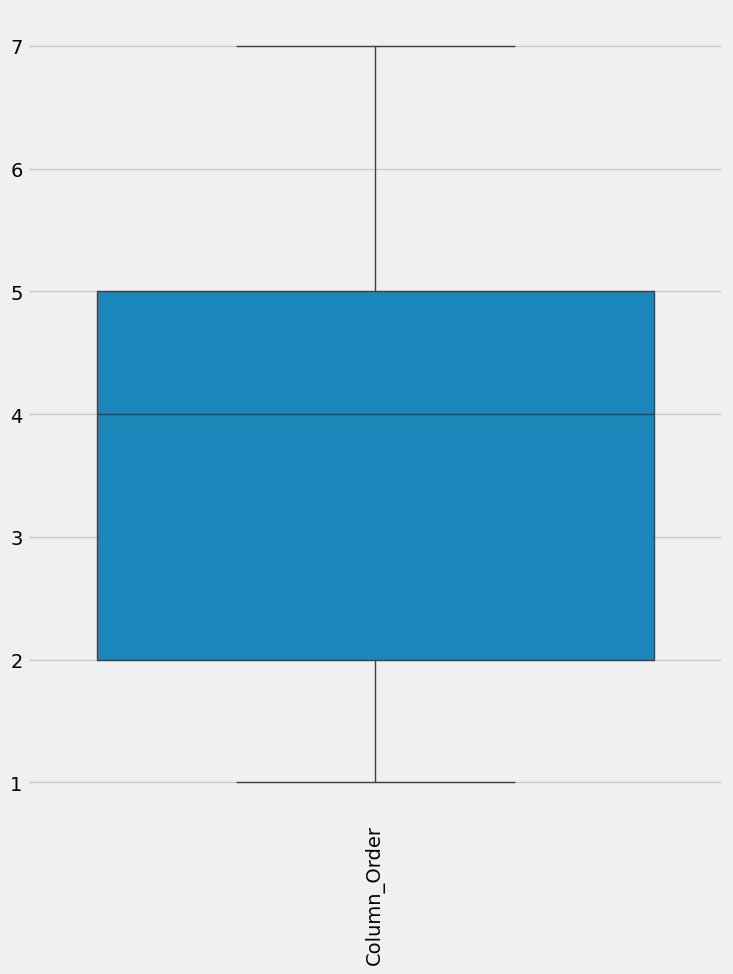

In [36]:
plt.figure(figsize=(8, 10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

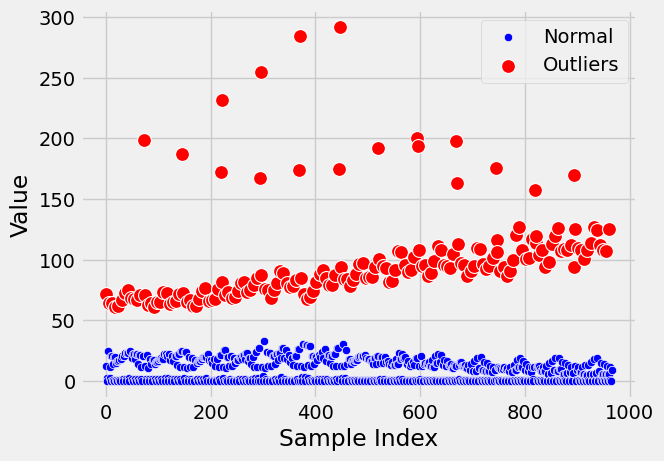

In [40]:
Q1 = df["Value"].quantile(0.25)
Q3 = df["Value"].quantile(0.75)
IQR = Q3 - Q1

# Condition for outliers
outliers = (df["Value"] < (Q1 - 1.5 * IQR)) | \
           (df["Value"] > (Q3 + 1.5 * IQR))

# Scatter plot with outliers in red
sns.scatterplot(x=df.index, y=df["Value"], label="Normal", color='blue')
sns.scatterplot(x=df.index[outliers], y=df["Value"][outliers],
                color="red", s=100, label="Outliers")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.legend()
plt.show()

In [41]:
# Calculate IQR
Q1 = df["Value"].quantile(0.25)
Q3 = df["Value"].quantile(0.75)
IQR = Q3 - Q1

# Filter in place (keep only non-outliers)
df = df[(df["Value"] >= (Q1 - 1.5 * IQR)) & 
        (df["Value"] <= (Q3 + 1.5 * IQR))]

# Reset index (optional)
df = df.reset_index(drop=True)

print(f"Dataset after outlier removal: {df.shape}")

Dataset after outlier removal: (787, 6)


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787 entries, 0 to 786
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   MSN           787 non-null    object        
 1   Value         787 non-null    float64       
 2   Column_Order  787 non-null    int64         
 3   Description   787 non-null    object        
 4   Unit          787 non-null    object        
 5   datetime      787 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 37.0+ KB


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Missing Handking
</center></p></h1>


In [38]:
df['Value'].replace('Not Available', np.nan, inplace=True)   #
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

In [39]:
# Fill missing values using ffill method
df.fillna(method='ffill', inplace=True)  # Forward fill to maintain continuity
df.info() # Verify that there are no missing values left

<class 'pandas.core.frame.DataFrame'>
Index: 965 entries, 0 to 966
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   MSN           965 non-null    object        
 1   Value         965 non-null    float64       
 2   Column_Order  965 non-null    int64         
 3   Description   965 non-null    object        
 4   Unit          965 non-null    object        
 5   datetime      965 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 52.8+ KB


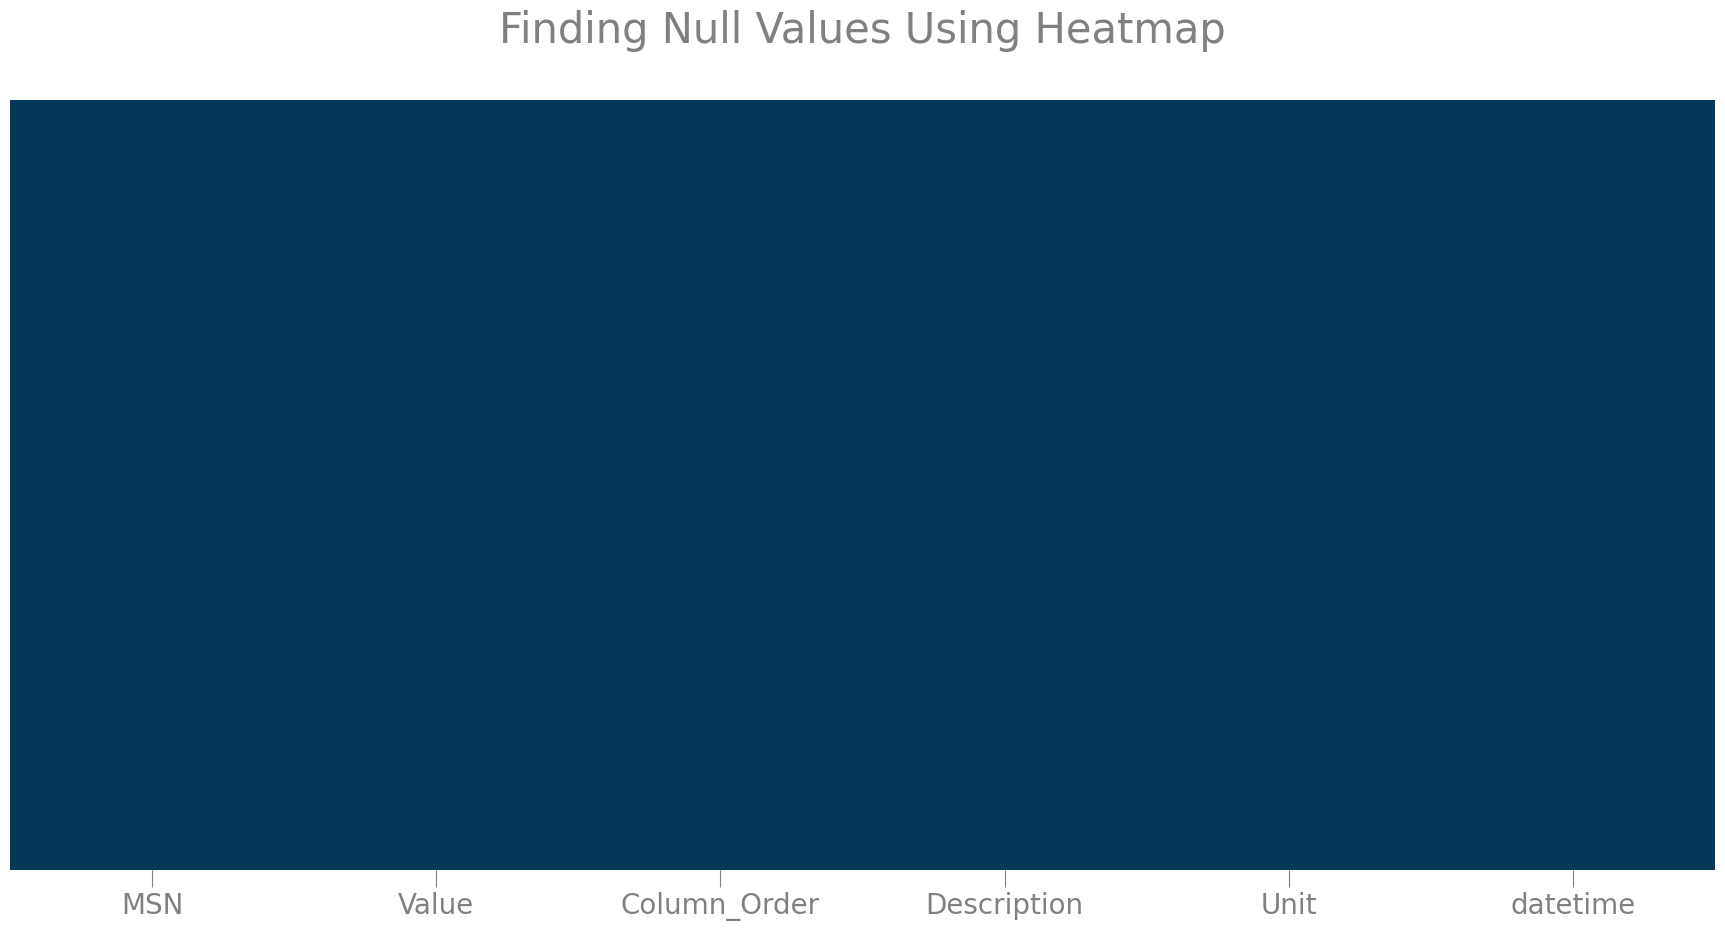

In [20]:
plt.figure(figsize=(22,10))
plt.xticks(size=20,color='grey')
plt.tick_params(size=12,color='grey')
plt.title('Finding Null Values Using Heatmap\n',color='grey',size=30)
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=False,
            cmap='PuBu_r',
            )
plt.show()

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Adding separate time and date columns  
      
</center></p></h1>

In [43]:



df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
df['day_of_year'] = df['datetime'].dt.dayofyear
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['season'] = (df['month'] % 12 // 3).map({
    0: "Winter",
    1: "Spring",
    2: "Summer",
    3: "Fall"
})


df.set_index('datetime', inplace=True)





In [44]:
df.head()

,MSN,Value,Column_Order,Description,Unit,hour,day_of_week,is_weekend,day_of_year,year,month,season
datetime,,,,,,,,,,,,
2013-01-01,NNEIEUS,12.175,2,Natural Gas Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide,0,1,0,1,2013,1,Winter
2013-01-01,DKEIEUS,2.375,3,"Distillate Fuel, Including Kerosene-Type Jet F...",Million Metric Tons of Carbon Dioxide,0,1,0,1,2013,1,Winter
2013-01-01,PCEIEUS,0.128,4,Petroleum Coke Electric Power Sector CO2 Emiss...,Million Metric Tons of Carbon Dioxide,0,1,0,1,2013,1,Winter
2013-01-01,RFEIEUS,24.867,5,Residual Fuel Oil Electric Power Sector CO2 Em...,Million Metric Tons of Carbon Dioxide,0,1,0,1,2013,1,Winter
2013-01-01,GEEIEUS,24.867,7,Geothermal Energy Electric Power Sector CO2 Em...,Million Metric Tons of Carbon Dioxide,0,1,0,1,2013,1,Winter


In [ ]:
# Add 1 hour to each timestamp
df['date_plus_1h'] = df['date'] + timedelta(hours=1)

# Subtract 24 hours
df['date_minus_24h'] = df['date'] - timedelta(hours=24)


# Forecast 72 hours into the future
last_date = df['date'].max()
future_dates = [last_date + timedelta(hours=i) for i in range(1, 73)]
future_df = pd.DataFrame({'date': future_dates})


In [55]:
df.columns

Index(['MSN', 'Value', 'Column_Order', 'Description', 'Unit', 'hour',
       'day_of_week', 'is_weekend', 'day_of_year', 'year', 'month', 'season'],
      dtype='object')

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Distribution and anlaysis data
</center></p></h1>

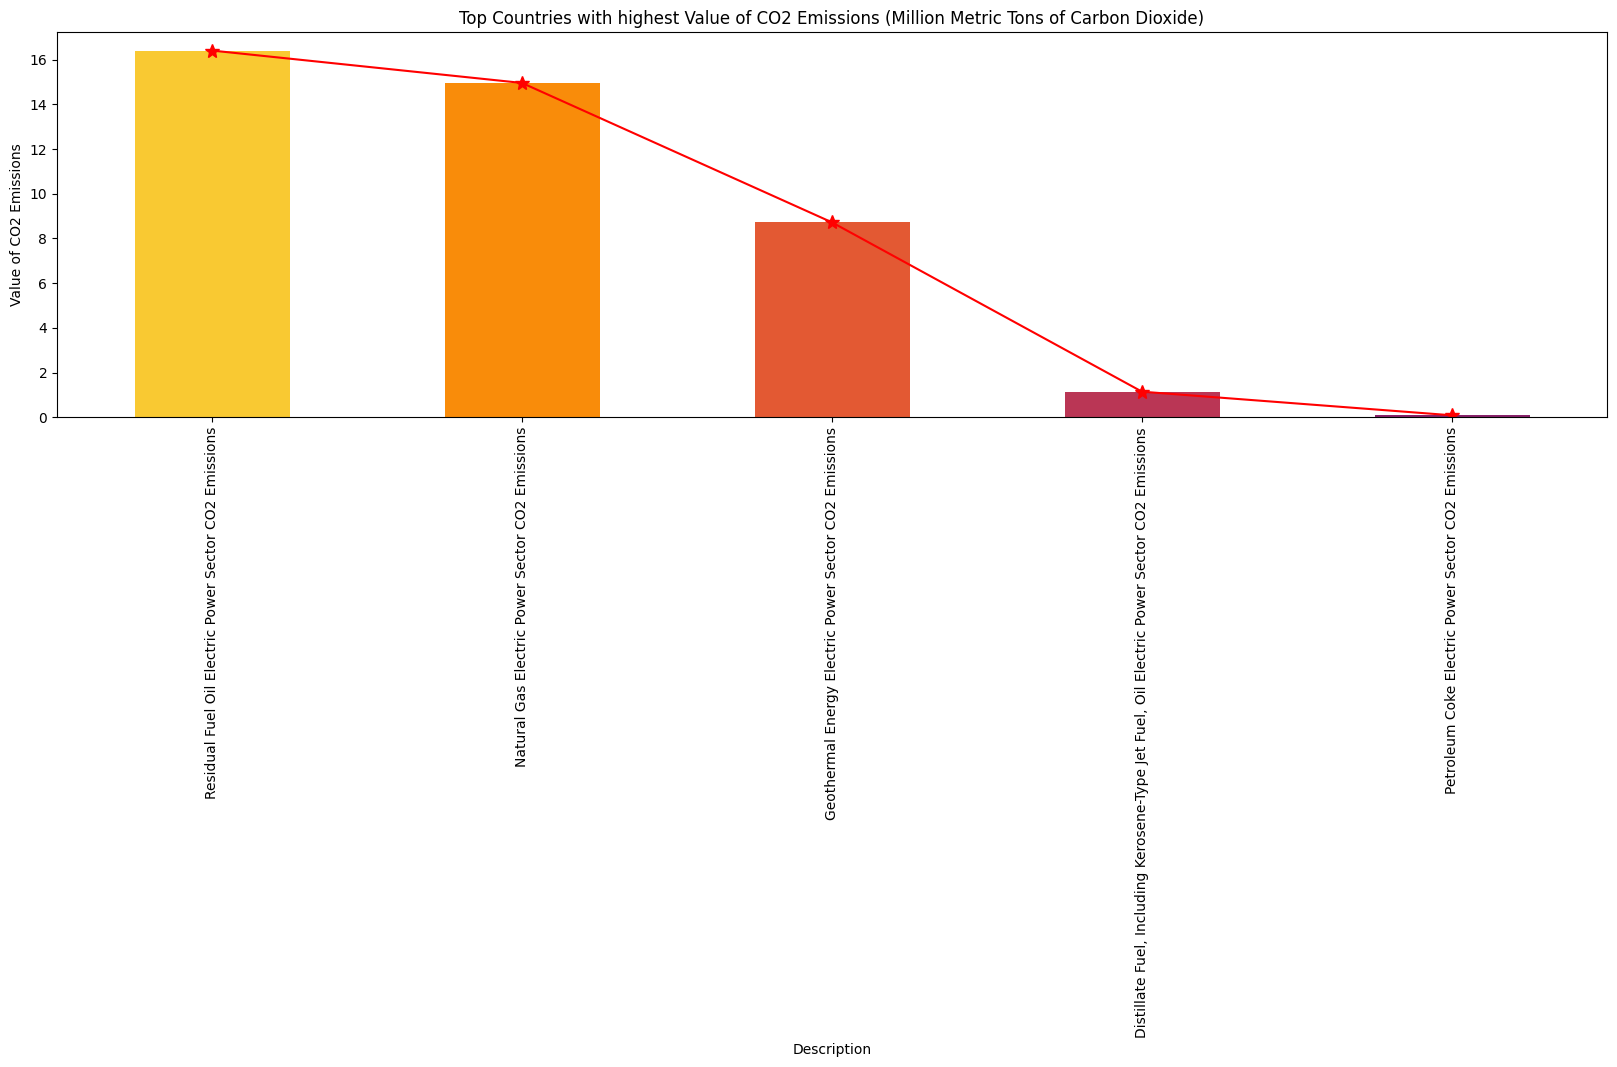

In [56]:
plt.figure(figsize=(20,5))
plt.title('Top Countries with highest Value of CO2 Emissions (Million Metric Tons of Carbon Dioxide)')
plt.ylabel('Value of CO2 Emissions')
df.groupby('Description')['Value'].mean().sort_values(ascending=False).plot(kind='line', marker='*', color='red', ms=10)
df.groupby('Description')['Value'].mean().sort_values(ascending=False).plot(kind='bar',color=sns.color_palette("inferno_r", 7))
plt.show()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; 
            text-align: justify; color: black; font-size: 14px; padding: 10px; 
            background:#F2FFFF;">
    <p>
        <b>From the bar chart,</b> we can see that the contribution of 
        <b>coal</b> to the total CO2 emission is significant, followed by 
        <b>natural gas</b>.
    </p>
</div>


<Axes: xlabel='datetime'>

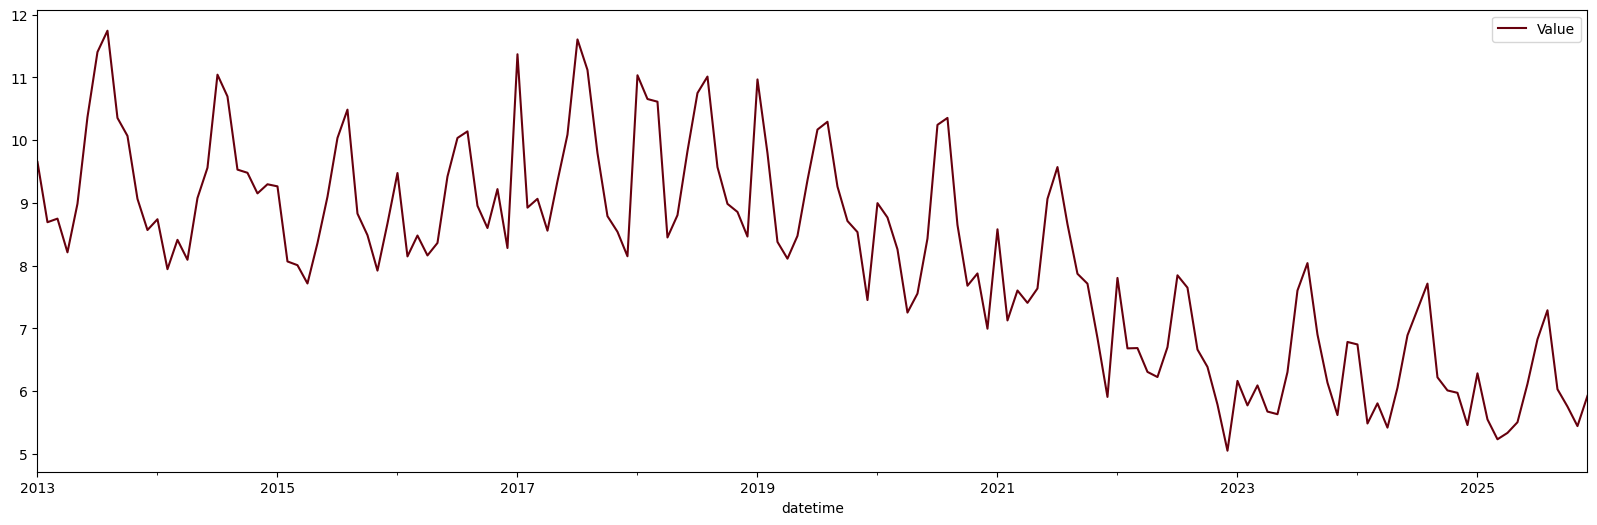

In [57]:

df.groupby(df.index)['Value'].mean().plot(
    legend=True,
    colormap='Reds_r',
    figsize=(20, 6)
)


# Check min and max date for data period


In [58]:
print(df.index.min(), df.index.max())
# Length of data
print(len(df))

2013-01-01 00:00:00 2025-12-01 00:00:00
788


# Evaluation of data by month, year, and calculate the CO2 emission

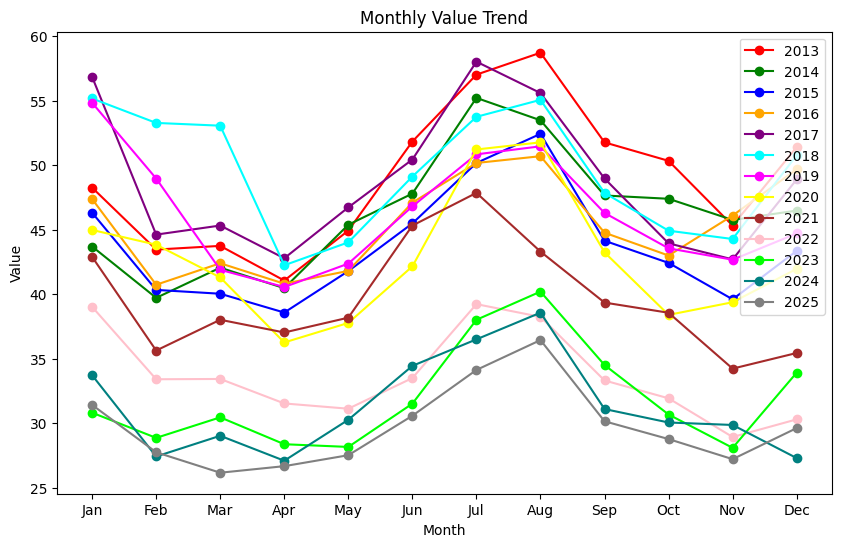

In [61]:

monthly_sales = df.groupby(['month', 'year'])['Value'].sum().reset_index()

# Create the line chart
plt.figure(figsize=(10, 6))  # Set the figure size

# Get unique years and cycle through colors
years = monthly_sales['year'].unique()
colors = itertools.cycle(['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta', 
    'yellow', 'brown', 'pink', 'lime', 'teal', 'gray'])

for year in years:
    year_data = monthly_sales[monthly_sales['year'] == year]
    plt.plot(year_data['month'], year_data['Value'], marker='o', color=next(colors), label=str(year))

plt.xlabel('Month')
plt.ylabel('Value')
plt.title('Monthly Value Trend')
# Customize x-axis ticks to show month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(1, 13), month_names)


plt.legend()
plt.show()


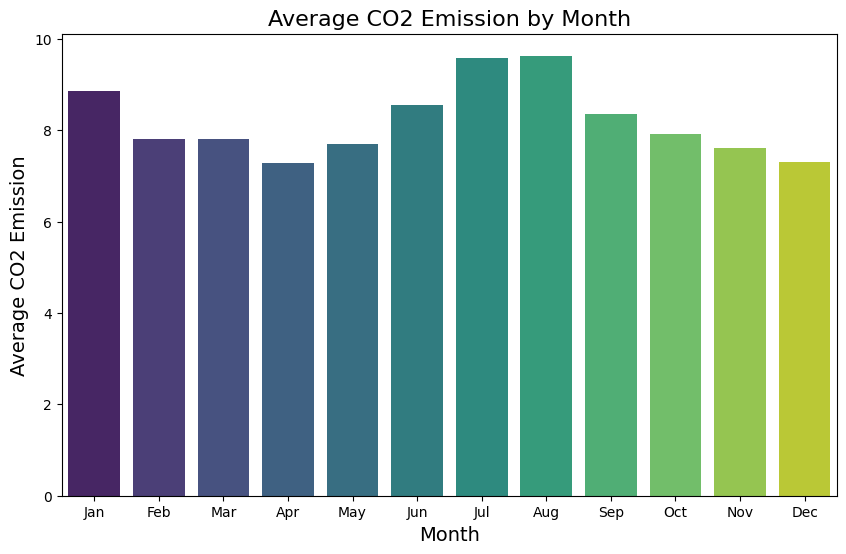

In [64]:
monthly_average_consumption = df.groupby('month')['Value'].mean().reset_index()
# bar plot
plt.figure(figsize=(10,6))
sns.barplot(x='month', y= 'Value', data = monthly_average_consumption, palette='viridis')
plt.title('Average CO2 Emission by Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average CO2 Emission', fontsize=14)
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; 
            text-align: justify; color: black; font-size: 14px; padding: 10px; 
            background:#F2FFFF;">
    <p>
        Analyzing the CO2 emissions from 2013 to 2025, we observe a 
        <b>gradual decrease over the years</b>. Additionally, emissions tend to 
        <b>peak between July and August</b>, indicating a seasonal pattern in CO2 output.
    </p>
</div>



In [66]:



df_1 = df[df["Value"] <= 400]


month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
df_1['month_name'] = df_1['month'].map(month_names)


fig = px.box(df_1, x='month_name', y='Value',
             title='Monthly Generation Patterns',
             labels={'month_name':'Month', 'Value':'CO2 Emissions'},
             color='month_name')

fig.update_layout(showlegend=False)
fig.show()


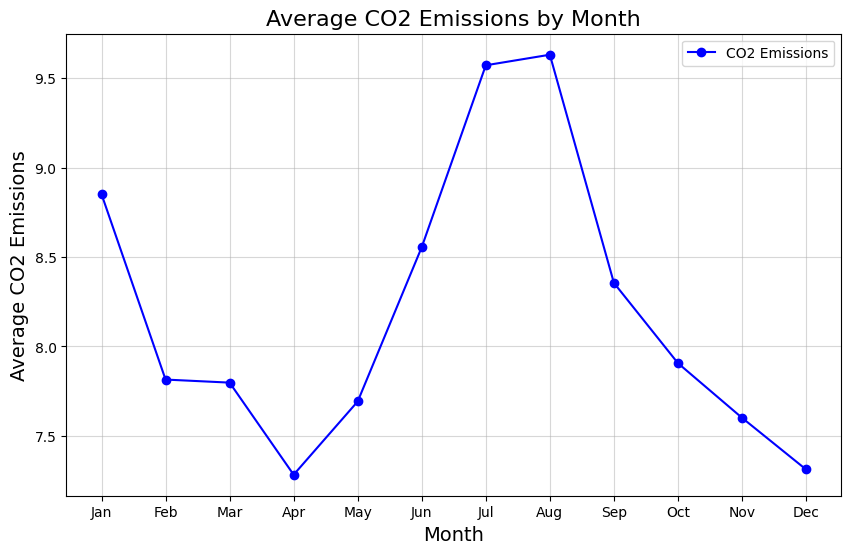

In [67]:
monthly_avg_consumption = df.groupby('month')['Value'].mean().reset_index()

# Line chart
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg_consumption['month'], 
         monthly_avg_consumption['Value'], 
         marker='o', color='b', label='CO2 Emissions')
plt.title('Average CO2 Emissions by Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average CO2 Emissions', fontsize=14)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(alpha=0.5)
plt.legend()
plt.show()

### CO2 Emission per year

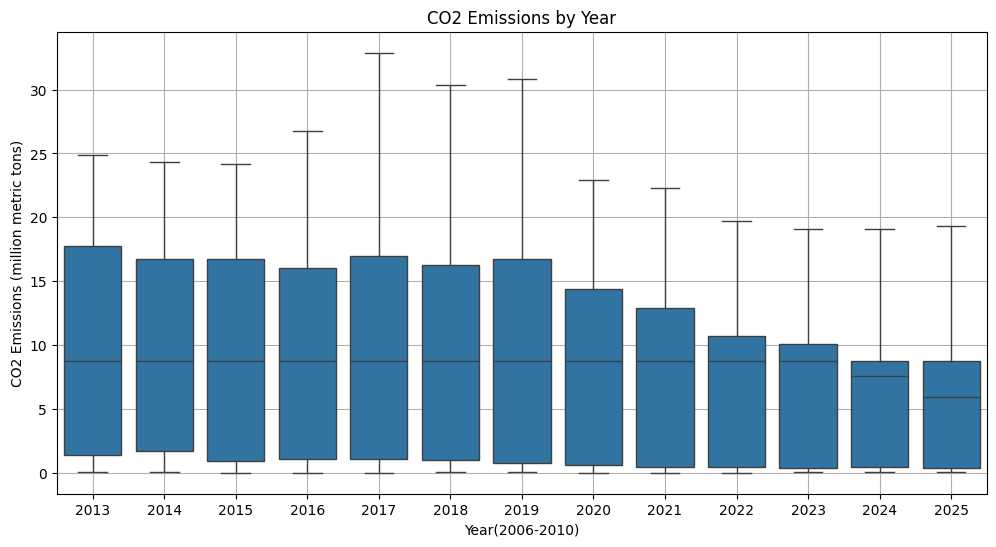

In [68]:
# Weekly sales by Type
plt.figure(figsize=(12,6))
sns.boxplot(x='year', y='Value', data=df)
plt.title('CO2 Emissions by Year')
plt.xlabel('Year(2006-2010)')
plt.ylabel('CO2 Emissions (million metric tons)')
plt.grid()
plt.show()

## CO2 Emission by seasonal

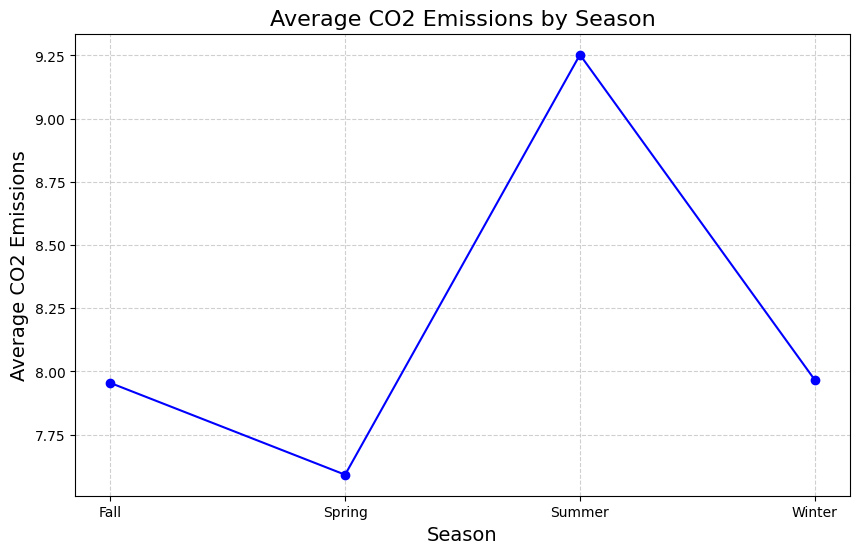

In [70]:
season_avg_consumption = df.groupby('season')['Value'].mean().reset_index()

# Line chart
plt.figure(figsize=(10, 6))
plt.plot(season_avg_consumption['season'], season_avg_consumption['Value'], marker='o', linestyle='-', color='b')
plt.title('Average CO2 Emissions by Season', fontsize=16)
plt.xlabel('Season', fontsize=14)
plt.ylabel('Average CO2 Emissions', fontsize=14)
plt.grid(visible=True, linestyle='--', alpha=0.6)
plt.show()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; 
            text-align: justify; color: black; font-size: 14px; padding: 10px; 
            background:#F2FFFF;">
    <p>
        The analysis indicates that <b>CO₂ emissions are higher during the summer season</b>, 
        suggesting increased energy demand and production in warmer months.
    </p>
</div>


# Plot average CO2 Emission by hour

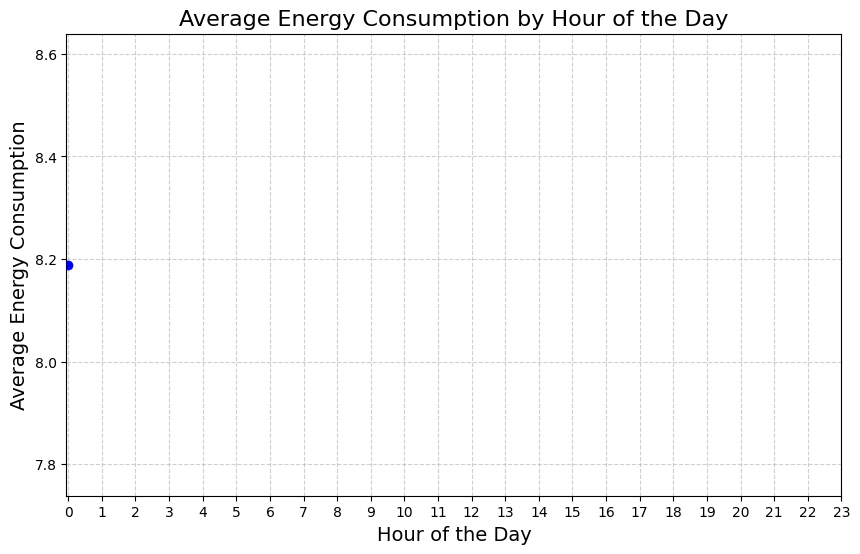

In [73]:
hour_avg_consumption = df.groupby('hour')['Value'].mean().reset_index()

# Line chart
plt.figure(figsize=(10, 6))
plt.plot(hour_avg_consumption['hour'], hour_avg_consumption['Value'], marker='o', linestyle='-', color='b')
plt.title('Average Energy Consumption by Hour of the Day', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=14)
plt.ylabel('Average Energy Consumption', fontsize=14)
plt.xticks(range(0, 24))  # Hour range from 0 to 23
plt.grid(visible=True, linestyle='--', alpha=0.6)
plt.show()

# Plot distribution of CO2 Emission



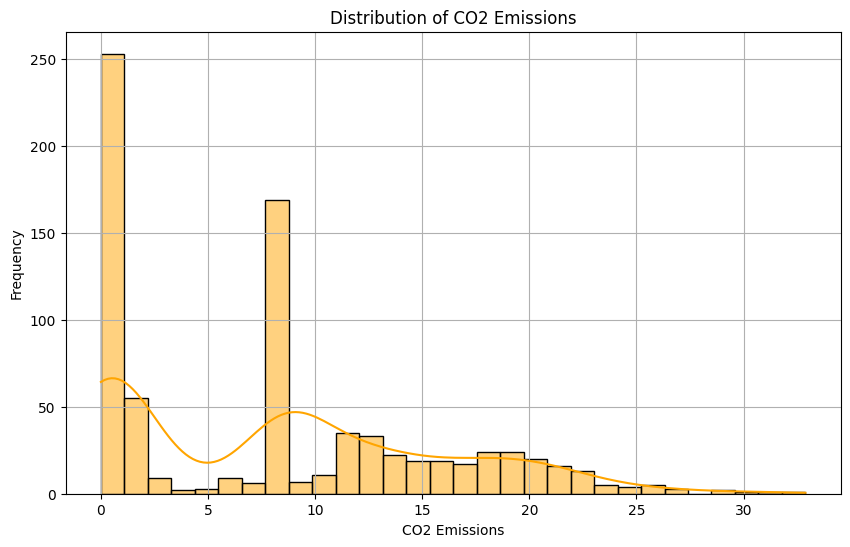

In [74]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Value'], kde=True, color='orange', bins=30)
plt.title('Distribution of CO2 Emissions')
plt.xlabel('CO2 Emissions')
plt.ylabel('Frequency')
plt.grid()
plt.show()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000;
            text-align: justify; color: black; font-size: 14px; padding: 12px;
            background:#F2FFFF;">

 <h4 style="color:#006400;">Observations</h4>
    <ul>
        <li>
            The distribution is <b>heavily right-skewed</b>, indicating that most entities
            exhibit low CO₂ emissions, while a small number produce exceptionally high emissions.
        </li>
        <li>
            The <b>highest frequency (approximately 250)</b> occurs in the lowest emissions bin,
            close to zero.
        </li>
        <li>
            Emission values <b>below 5 units are very common</b>, representing the majority of observations.
        </li>
        <li>
            Only a <b>small fraction of entities</b> have emissions exceeding 10–15 units.
        </li>
        <li>
            The distribution shows a <b>long right tail extending toward 30 units</b>,
            although frequencies in this range are nearly zero.
        </li>
    </ul>

<h4 style="color:#006400;">Possible Context</h4>
    <p>
        This distribution may represent <b>global CO₂ emissions by country</b>, where numerous
        small or less industrialized nations contribute minimally to emissions, while a few
        large, industrialized, or highly populated countries account for disproportionately
        high emission levels.
    </p>

 <h4 style="color:#006400;">Limitations</h4>
    <ul>
        <li>The X-axis does not specify the <b>measurement units</b>.</li>
        <li>The <b>sample size and data source</b> are not provided.</li>
        <li>The <b>bin width</b> used in the histogram is not explicitly stated.</li>
    </ul>

</div>


# Violin plot for CO2 Emission by Hour

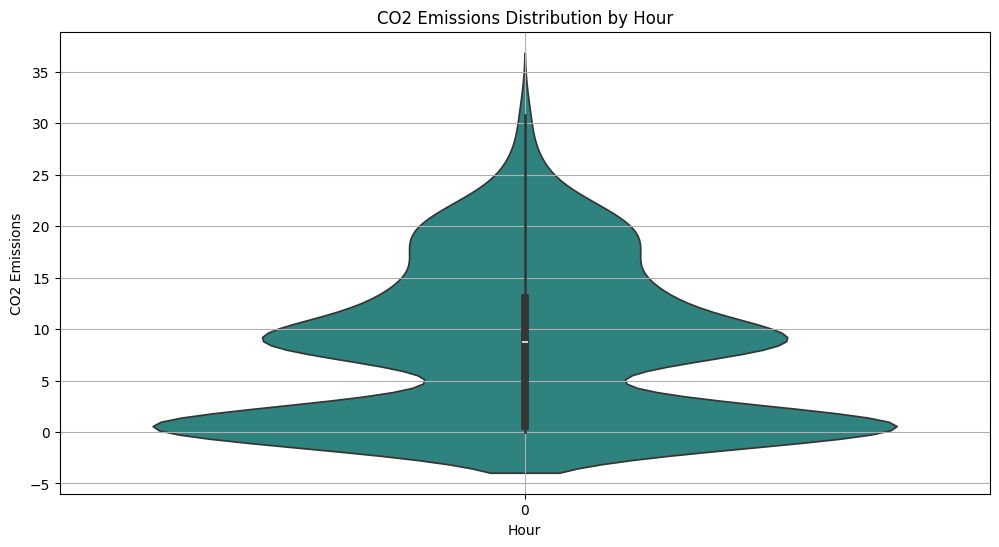

In [75]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='hour', y='Value', palette='viridis', scale='width')
plt.title('CO2 Emissions Distribution by Hour')
plt.xlabel('Hour')
plt.ylabel('CO2 Emissions')
plt.grid()
plt.show()

# Total Production Distribution Among Sources 

In [81]:
df.columns

Index(['MSN', 'Value', 'Column_Order', 'Description', 'Unit', 'hour',
       'day_of_week', 'is_weekend', 'day_of_year', 'year', 'month', 'season'],
      dtype='object')

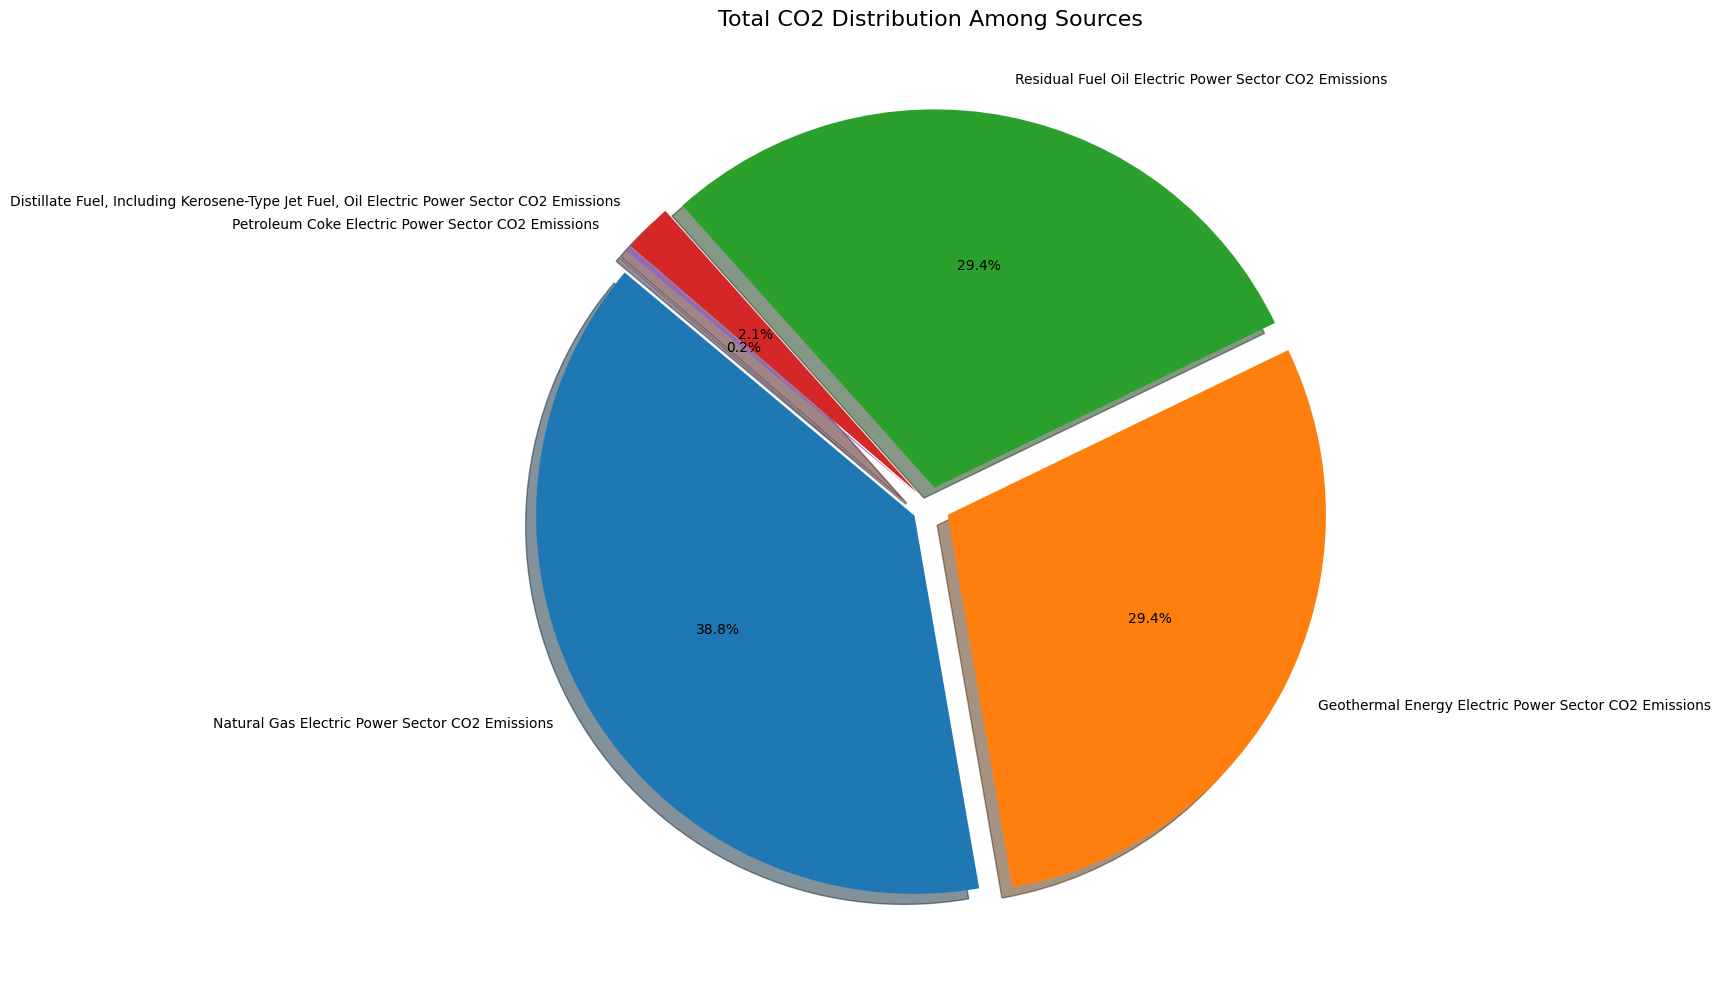

In [85]:

grouped_total_yield = df.groupby('Description')['Value'].last()

# Sort values
grouped_total_yield = grouped_total_yield.sort_values(ascending=False)

# Create explode values (slight separation for all slices)
explode = [0.05] * len(grouped_total_yield)

# Plot pie chart with slices (explode)
plt.figure(figsize=(18, 10))
grouped_total_yield.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    shadow=True
)

plt.title('Total CO2 Distribution Among Sources', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.show()


<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000;
            text-align: justify; color: black; font-size: 14px; padding: 12px;
            background:#F2FFFF;">

 <p>
        This pie chart illustrates the <b>distribution of CO₂ emissions among fuel sources in the Electric Power Sector</b>.
        <b>Natural Gas</b> contributes the largest share (~38.8%), followed by
        <b>Residual Fuel Oil</b> and <b>Distillate Fuel</b>, each accounting for approximately 29.4%.
        <b> Petroleum Coke</b> represents a very small fraction (~0.24%), while
        <b>Geothermal Energy</b> emissions are negligible.
    </p>

  <p>
        Overall, the chart highlights a strong reliance on petroleum-based fuels for power generation,
        though the results are limited to the electric power sector and lack clear geographic
        and temporal context.
    </p>

</div>


# Hourly Average CO2 Emission by Month (Jan to Mar)-2 

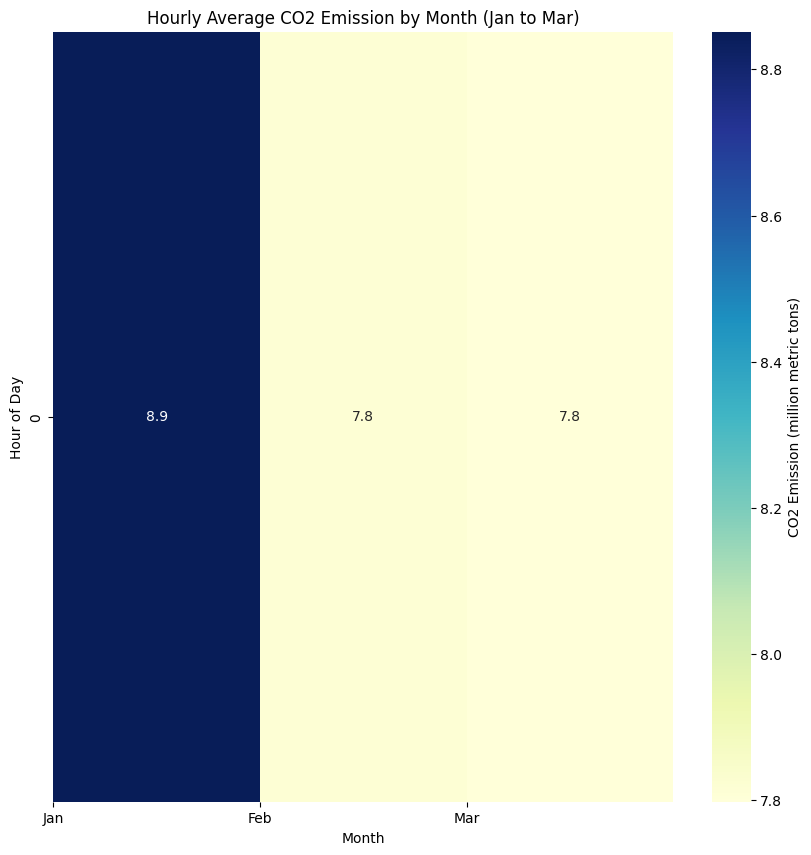

In [88]:
pivot_temp_month = df.groupby(['hour', 'month'])['Value'].mean().unstack()

pivot_temp_first_3_months = pivot_temp_month.iloc[:, :3]

plt.figure(figsize=(10, 10))
sns.heatmap(pivot_temp_first_3_months, cmap="YlGnBu", annot=True, fmt=".1f", cbar_kws={'label': 'CO2 Emission (million metric tons)'})
plt.title('Hourly Average CO2 Emission by Month (Jan to Mar)')
plt.xlabel('Month')
plt.ylabel('Hour of Day')
plt.xticks(ticks=range(0,3), labels=['Jan', 'Feb', 'Mar'])
plt.show()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000;
            text-align: justify; color: black; font-size: 14px;
            padding: 10px; background:#F2FFFF;">

  <p>
    This heatmap illustrates the <b>hourly average ambient temperature</b> for the 
    first three months of the year (January, February, and March). The color intensity 
    represents the temperature, with darker shades indicating higher temperatures.
  </p>

  <p style="background:#E6FFFA; padding:8px; border-left:4px solid #008000;">
    <b>Insight:</b> The visualization highlights that temperatures are generally lower 
    during the morning hours, which can influence solar panel efficiency and daily 
    energy production patterns.
  </p>

</div>


## Correlation Analysis

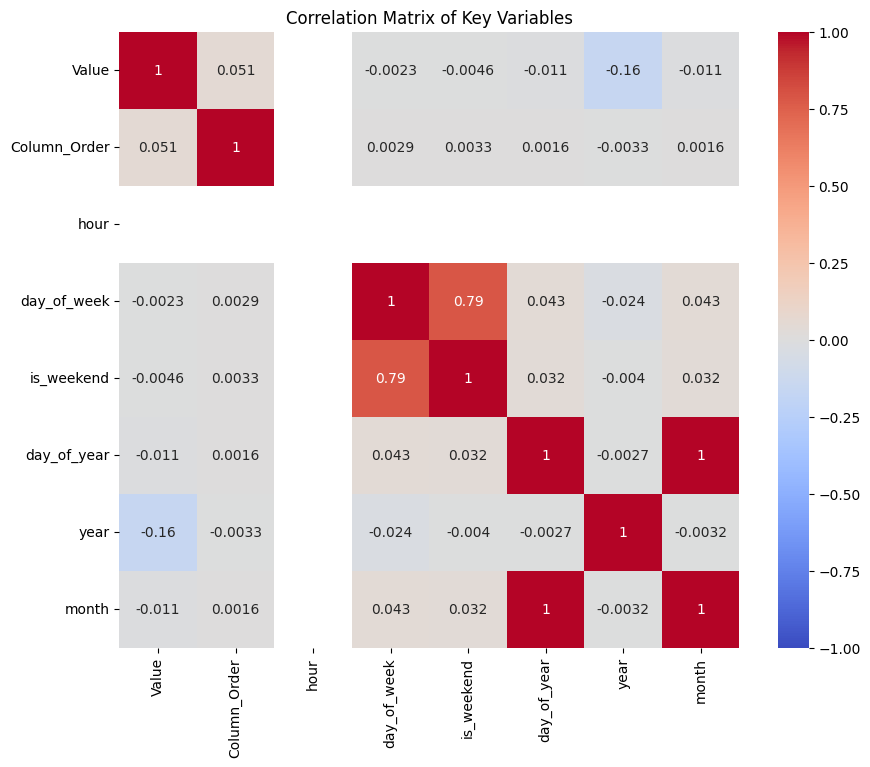

In [89]:
correlation_matrix_english = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_english, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Key Variables')
plt.show()

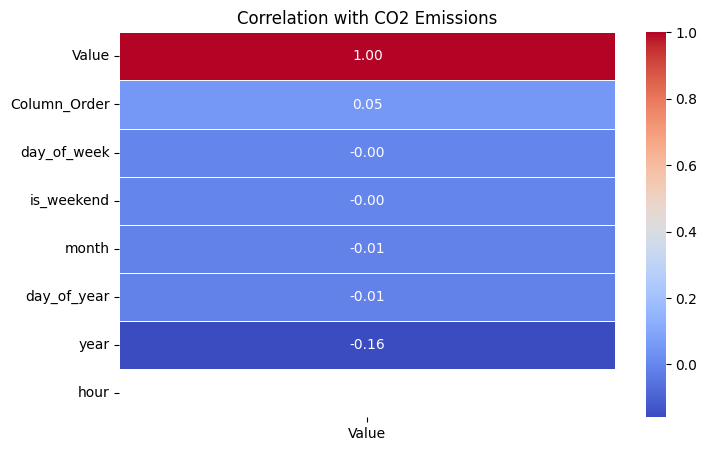

In [90]:
correlation_matrix = df.corr(numeric_only=True)
correlation_price = correlation_matrix['Value'].sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_price.to_frame(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation with CO2 Emissions')
plt.show()

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Feature Engineering-Natural gas CO2 emission analysis
</center></p></h1>

In [13]:
df["Description"]

datetime
2013-01-01      Natural Gas Electric Power Sector CO2 Emissions
2013-02-01      Natural Gas Electric Power Sector CO2 Emissions
2013-03-01      Natural Gas Electric Power Sector CO2 Emissions
2013-04-01      Natural Gas Electric Power Sector CO2 Emissions
2013-05-01      Natural Gas Electric Power Sector CO2 Emissions
                                    ...                        
2025-08-01    Geothermal Energy Electric Power Sector CO2 Em...
2025-09-01    Geothermal Energy Electric Power Sector CO2 Em...
2025-10-01    Geothermal Energy Electric Power Sector CO2 Em...
2025-11-01    Geothermal Energy Electric Power Sector CO2 Em...
2025-12-01    Geothermal Energy Electric Power Sector CO2 Em...
Name: Description, Length: 788, dtype: object

In [45]:
ts=df[df["Description"]=="Natural Gas Electric Power Sector CO2 Emissions"]

In [46]:
ts.head()

,MSN,Value,Column_Order,Description,Unit,hour,day_of_week,is_weekend,day_of_year,year,month,season
datetime,,,,,,,,,,,,
2013-01-01,NNEIEUS,12.175,2,Natural Gas Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide,0,1,0,1,2013,1,Winter
2013-02-01,NNEIEUS,11.708,2,Natural Gas Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide,0,4,0,32,2013,2,Winter
2013-03-01,NNEIEUS,13.994,2,Natural Gas Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide,0,4,0,60,2013,3,Spring
2013-04-01,NNEIEUS,14.627,2,Natural Gas Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide,0,0,0,91,2013,4,Spring
2013-05-01,NNEIEUS,17.344,2,Natural Gas Electric Power Sector CO2 Emissions,Million Metric Tons of Carbon Dioxide,0,2,0,121,2013,5,Spring


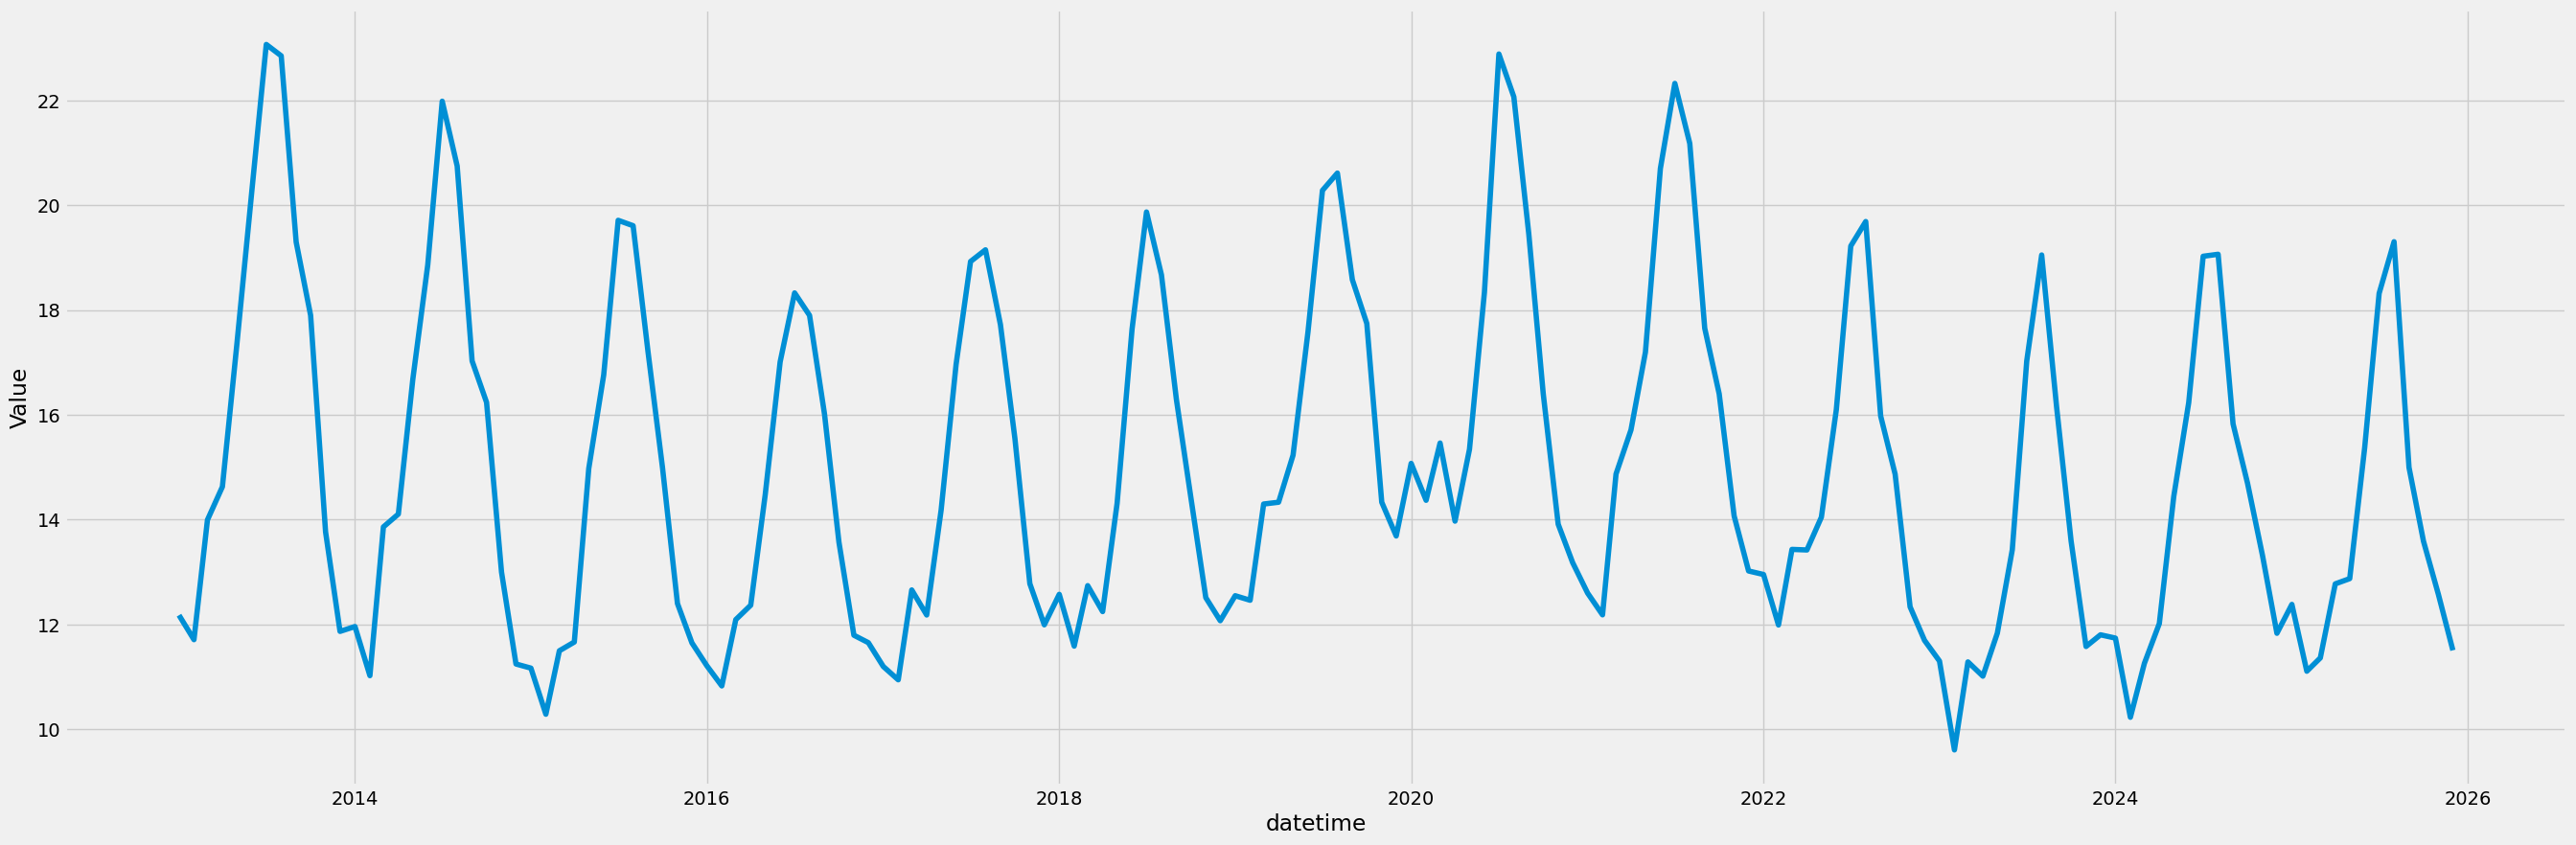

In [47]:
plt.figure(figsize=(30,10))
fig = sns.lineplot(x='datetime', y='Value', data=ts, palette='viridis')

<Figure size 1280x960 with 0 Axes>

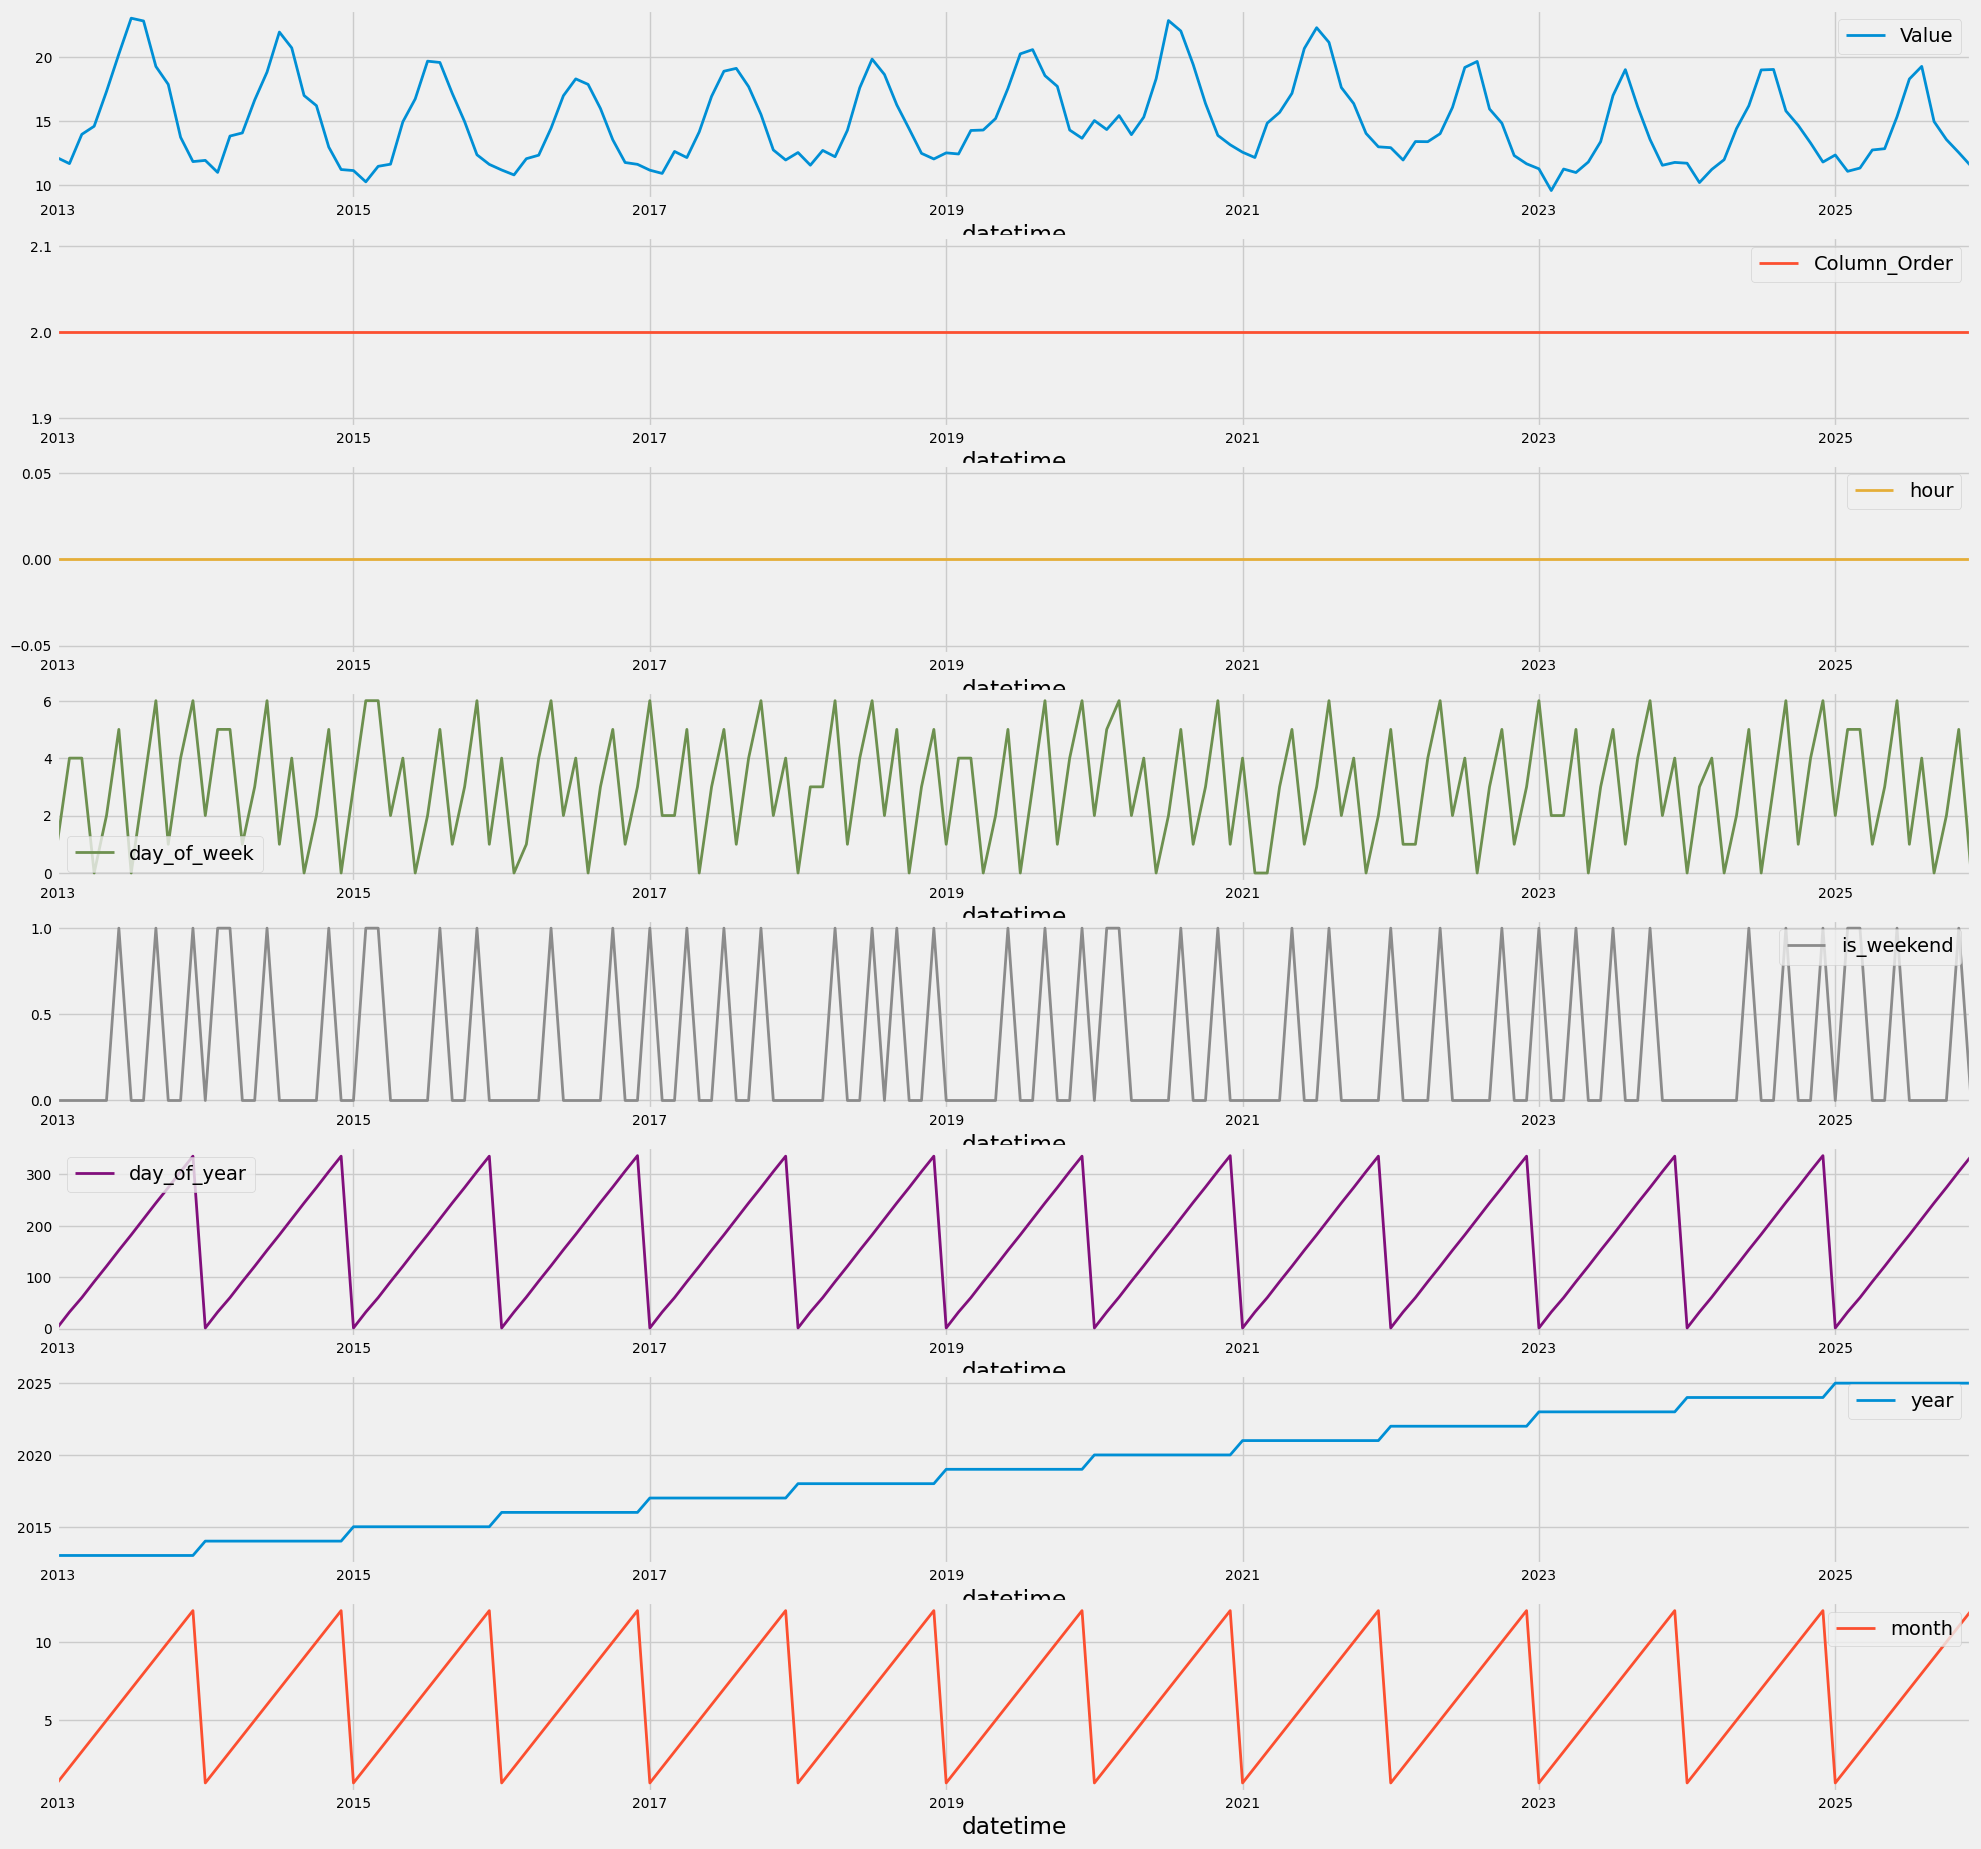

In [48]:
# Visualization of the primary dataset
plt.figure(dpi=200)
plt.style.use('fivethirtyeight')
ts.plot(subplots=True, figsize=(22, 22), fontsize=10, linewidth=2, sharex=False)
plt.show()

# Volatility Plot

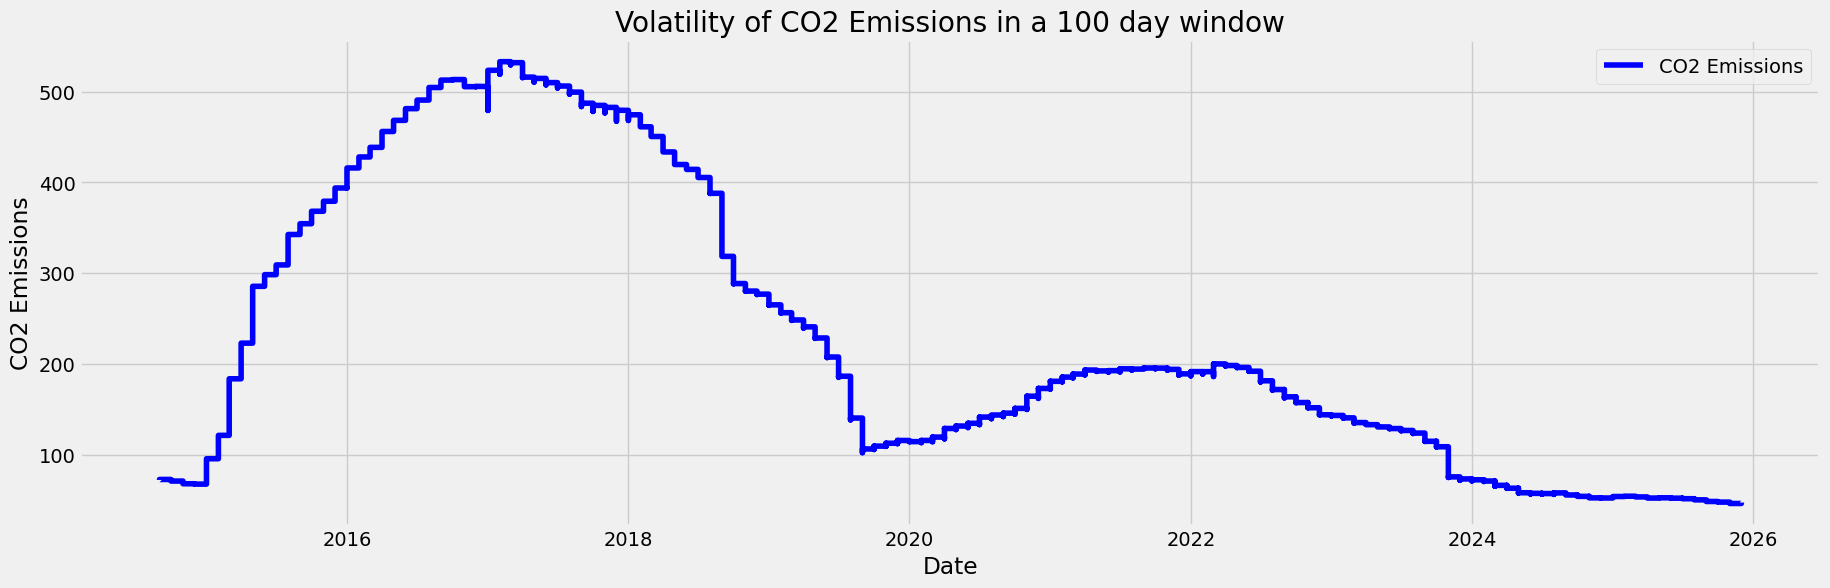

In [57]:
df['Value_Change'] = df['Value'].pct_change()
window_size = 100
df_100 = df['Value_Change'].rolling(window = window_size).std()


#plotting
plt.figure(figsize = (20,6))
plt.plot(df.index , df_100 , label = 'CO2 Emissions' , color = 'blue')
plt.title('Volatility of CO2 Emissions in a 100 day window')
plt.xlabel('Date')
plt.ylabel('CO2 Emissions')
plt.legend()
plt.grid(True)
plt.show()

#  Spike Definition

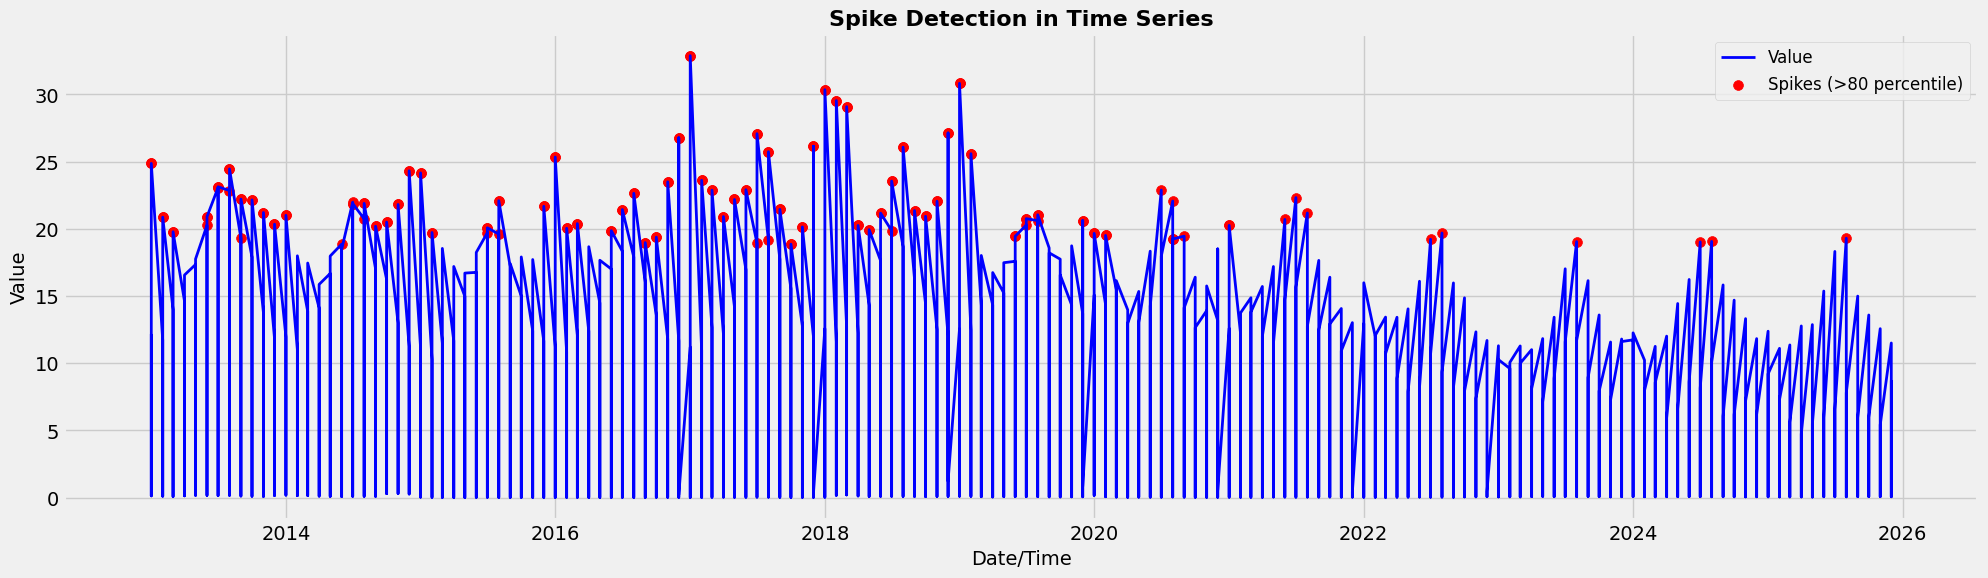

In [49]:


SPIKE_Q = 0.8 
spike_threshold = df['Value'].quantile(SPIKE_Q)


df['Value_spike'] = (df['Value'] > spike_threshold).astype(int)


plt.figure(figsize=(22,6))
plt.plot(df['Value'], label='Value', color='blue', linewidth=2)


plt.scatter(
    df.index[df['Value_spike']==1], 
    df['Value'][df['Value_spike']==1], 
    color='red', 
    label=f'Spikes (>{SPIKE_Q*100:.0f} percentile)', 
    s=50
)


plt.title('Spike Detection in Time Series', fontsize=16, fontweight='bold')
plt.xlabel('Date/Time', fontsize=14)
plt.ylabel('Value', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


# Rolling Volatility (7، 30، 365)

In [ ]:
df['price_vol_7']   = df['Value'].rolling(7).std()
df['price_vol_30']  = df['Value'].rolling(30).std()
df['price_vol_365'] = df['Value'].rolling(365).std()

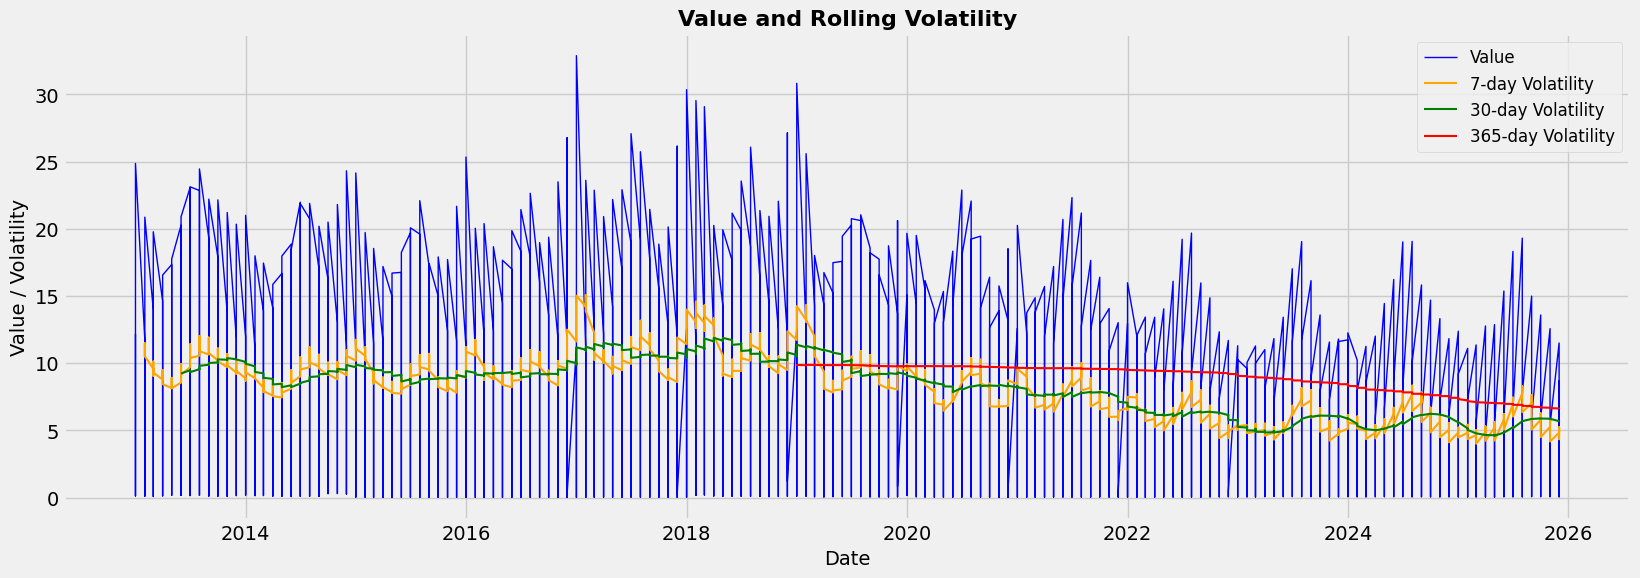

In [ ]:


# --- Compute rolling volatility ---
df['Value_vol_7']   = df['Value'].rolling(window=7).std()     # 1 week (if daily data)
df['Value_vol_30']  = df['Value'].rolling(window=30).std()    # 1 month
df['Value_vol_365'] = df['Value'].rolling(window=365).std()   # 1 year

# --- Plot original series + volatility ---
plt.figure(figsize=(18,6))

# Original values
plt.plot(df['Value'], label='Value', color='blue', linewidth=1)

# Rolling volatility
plt.plot(df['Value_vol_7'], label='7-day Volatility', color='orange', linewidth=1.5)
plt.plot(df['Value_vol_30'], label='30-day Volatility', color='green', linewidth=1.5)
plt.plot(df['Value_vol_365'], label='365-day Volatility', color='red', linewidth=1.5)

plt.title('Value and Rolling Volatility', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Value / Volatility', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


<div style="border-radius: 5px; font-family: Arial, sans-serif; 
            border: 3px solid #008000; text-align: justify; 
            color: black; font-size: 14px; padding: 10px; 
            background:#F2FFFF;">
Over the past decade, this metric has shown overall growth but experienced significant volatility during crisis periods (2020 and 2022–2023). Short-term volatility responds quickly to shocks, whereas long-term volatility reflects the sustained impact of turbulence. Future projections indicate stabilizing conditions with continued growth.
</div>


In [55]:
# --- 1. Example: Create lag features ---

df['Lag_1'] = df['Value'].shift(1)    # previous day
df['Lag_7'] = df['Value'].shift(7)    # 1 week ago
df['Lag_30'] = df['Value'].shift(30)  # 1 month ago
df['Lag_60'] = df['Value'].shift(60)  # 2 months ago

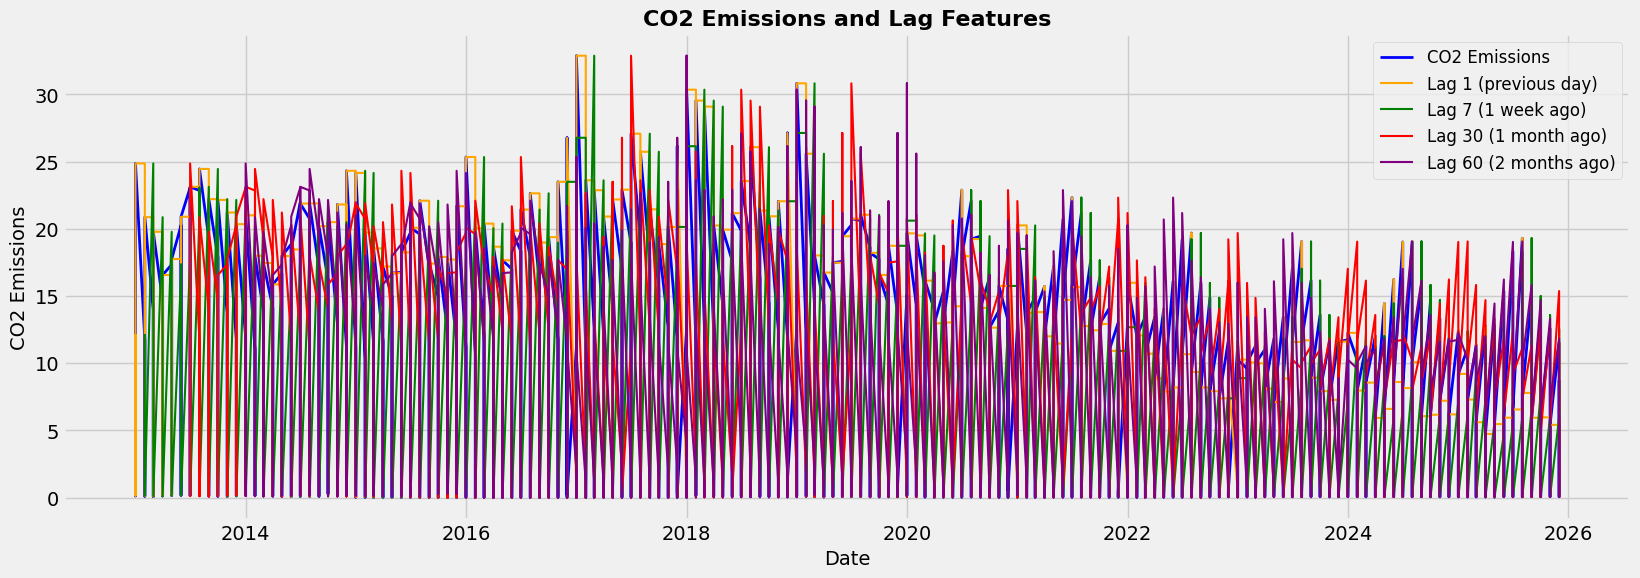

In [56]:


plt.figure(figsize=(18,6))

# Original series
plt.plot(df['Value'], label='CO2 Emissions', color='blue', linewidth=2)

# Lag features
plt.plot(df['Lag_1'], label='Lag 1 (previous day)', color='orange', linewidth=1.5)
plt.plot(df['Lag_7'], label='Lag 7 (1 week ago)', color='green', linewidth=1.5)
plt.plot(df['Lag_30'], label='Lag 30 (1 month ago)', color='red', linewidth=1.5)
plt.plot(df['Lag_60'], label='Lag 60 (2 months ago)', color='purple', linewidth=1.5)

plt.title('CO2 Emissions and Lag Features', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('CO2 Emissions', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

## To Observe 4-weeks Rolling Mean and Std

In [52]:
# For daily data, assuming 7 days per week
window = 4 * 7  # 4 weeks
roll_mean = df['Value'].rolling(window=window).mean()
roll_std  = df['Value'].rolling(window=window).std()

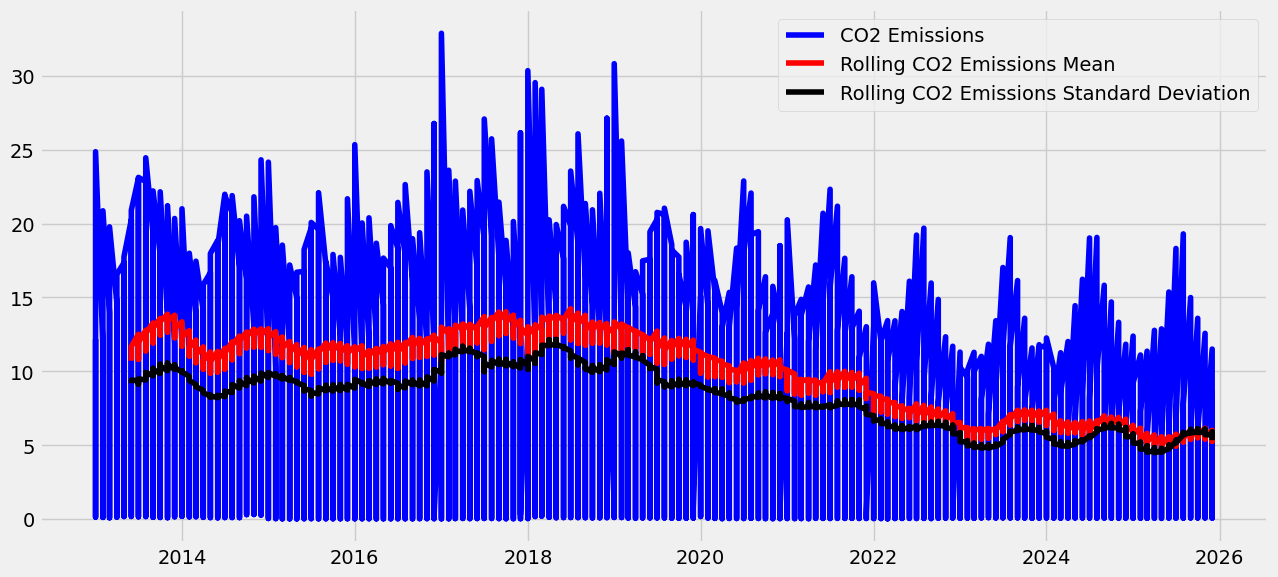

In [53]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df['Value'], color='blue',label='CO2 Emissions')
ax.plot(roll_mean, color='red', label='Rolling CO2 Emissions Mean')
ax.plot(roll_std, color='black', label='Rolling CO2 Emissions Standard Deviation')
ax.legend()
fig.tight_layout()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; 
            text-align: justify; color: black; font-size: 14px; padding: 10px; 
            background:#F2FFFF;">
The analysis of CO₂ emissions from 2014 to 2026 reveals notable trends and variability. Between 2014 and 2020, emissions fluctuated moderately around a relatively stable mean. A significant dip occurred in 2020, likely due to the COVID-19 pandemic, followed by a rapid recovery during 2020–2022. From 2022 onwards, emissions have been steadily increasing, with projections indicating this upward trend will continue through 2026. The standard deviation widened around 2020–2022, reflecting greater uncertainty during the pandemic and recovery period, while recent years (2024–2026) show more consistent variability. Overall, the temporary pandemic-induced reduction did not alter the long-term upward trajectory of emissions, suggesting that current climate policies may be insufficient to curb CO₂ growth and highlighting the need for stronger interventions.
</div>



<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> Models</p>
</div>

# ================================
# Time series

# ================================

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Check for stationarity by Adfuller
</center></p></h1>

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; 
            text-align: justify; color: black; font-size: 14px; 
            padding: 10px; background:#F2FFFF;">

  <h2>📈 Stationarity</h2>

  <p>
    <b>In time series analysis, stationarity refers to a property of a series where its statistical properties 
    (like mean, variance, and autocorrelation) are constant over time.</b>
  </p>

  <p>
    Stationarity plays a vital role in time series analysis. When we grasp this concept, we gain insights into 
    which methods are suitable for our data and how we can enhance forecast accuracy. By converting non-stationary 
    data, we can apply various statistical tools to understand and predict time series behavior.
  </p>

  <p>
    Imagine you're trying to predict the weather. Stationarity is like having consistent weather patterns. 
    If it's usually sunny in summer and rainy in winter, that's stationary. But if the weather goes crazy with 
    random heat waves and snowstorms, that's non-stationary.
  </p>

  <p>
    Many forecasting tools work best with consistent patterns. By smoothing out wild swings in your data 
    (making the “crazy weather” more predictable), you can make better forecasts for your time series.
  </p>

  <p style="text-align:center;">
    <img src="https://miro.medium.com/v2/resize:fit:1147/1*xdblkZyg6YmmReAkZHUksw.png" 
         alt="stationarity" style="max-width:100%; height:auto; border-radius:5px;">
  </p>

  <h3>🔹 Intuitive Explanation</h3>
  <p>
    Imagine a time series like a river flowing at a constant rate. The average water level (mean) stays the same, 
    and the fluctuations around that average (variance) are consistent throughout the river's course. 
    This is a stationary series.
  </p>
  <p>
    In contrast, a non-stationary series would be like a river with changing water levels — flooding seasonally 
    or drying up over time. The mean and variability change depending on the season or long-term trends.
  </p>

  <h3>🔹 Formal Definition</h3>
  <p>A time series is stationary if:</p>
  <ul>
    <li><b>Mean is constant:</b> The average value of the series does not trend upward or downward.</li>
    <li><b>Variance is constant:</b> The spread of the data points around the mean remains consistent.</li>
    <li><b>Autocorrelation is constant:</b> Relationships between observations at different lags do not change over time.</li>
  </ul>

  <h3>🔹 Why Stationarity Matters</h3>
  <p>
    Many statistical methods for time series forecasting assume stationarity. Non-stationary data may produce unreliable results:
  </p>
  <ul>
    <li><b>Forecasting:</b> Predicting future values is difficult if patterns change over time.</li>
    <li><b>Statistical Tests:</b> Validity of tests often relies on stationary data.</li>
  </ul>

  <h3>🔹 Transforming Non-Stationary Data</h3>
  <p>Common techniques to make a series stationary include:</p>
  <ul>
    <li><b>Differencing:</b> Subtracting a previous value from the current value to remove trends.</li>
    <li><b>Detrending:</b> Fitting a trend line and subtracting it from the series to remove long-term trends.</li>
    <li><b>Seasonal Adjustment:</b> Seasonal differencing or adjustments remove seasonal patterns.</li>
  </ul>

</div>


In [59]:

sample_series = df['Value'].sample(frac=0.2, random_state=42)
adf_result = adfuller(sample_series)
print("ADF Statistic:", adf_result[1])
print("p-value:", adf_result[1])

ADF Statistic: 7.409762011500381e-23
p-value: 7.409762011500381e-23




<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; 
text-align: justify; color: black; font-size: 14px; padding: 12px; background:#F2FFFF;">

  <p style="font-size: 14px; color: green; font-weight: bold;">
      📊 Augmented Dickey-Fuller (ADF) Test
  </p>

  <p>
      The <strong>Augmented Dickey-Fuller (ADF) test</strong> is a statistical test used to determine whether a time series is 
      <strong>stationary or non-stationary</strong>. Stationarity is extremely important in many time series models such as ARIMA.
  </p>

  <p>
     The ADF test evaluates the <strong>null hypothesis</strong> that the time series contains a <em>unit root</em>, meaning 
     that it is <strong>non-stationary</strong>. The alternative hypothesis suggests the series <strong>is stationary</strong>.
  </p>

  <p>
     When running the ADF test, two values are mainly interpreted:
  </p>

  <ul style="font-family: cursive; font-size: 14px;">
      <li><strong>ADF Statistic</strong> – negative value, the more negative → stronger evidence of stationarity</li>
      <li><strong>p-value</strong> – if below <strong>0.05</strong>, reject the null hypothesis</li>
  </ul>

  <p>
     A low p-value indicates strong evidence against the presence of a unit root and therefore supports that 
     the <strong>time series is stationary</strong>.
  </p>

  <p style="font-size: 14px; color: green; font-weight: bold;">
      ✔ Key Insights
  </p>

  <ul style="font-family: cursive; font-size: 14px;">
      <li>Time series <strong>must be stationary</strong> before applying ARIMA</li>
      <li><strong>AIC optimization</strong> helps select the best ARIMA parameters</li>
      <li>ARIMA is effective for data with <strong>trend</strong> and <strong>seasonality</strong></li>
  </ul>

</div>



<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     Method for stationarity
</center></p></h1>

## Differencing

In [60]:
# This process is meant to transform the time series data to stationary, as ARIMA model only works with stationary time series data. 
df['diff_value'] = df['Value'].diff()
print(df['diff_value'])

datetime
2013-01-01       NaN
2013-01-01    -9.800
2013-01-01    -2.247
2013-01-01    24.739
2013-01-01     0.000
               ...  
2025-12-01     6.093
2025-12-01   -10.891
2025-12-01    -0.552
2025-12-01     8.655
2025-12-01     0.000
Name: diff_value, Length: 787, dtype: float64


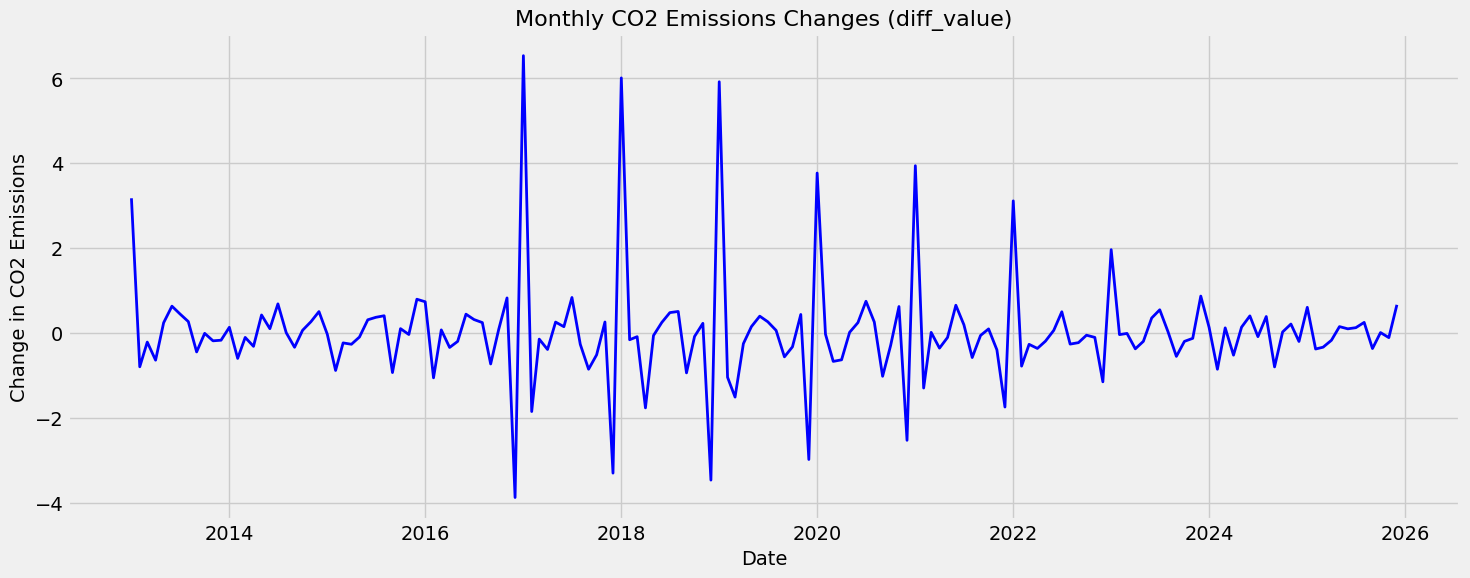

In [61]:
monthly_series = df['diff_value'].groupby(df.index).mean()
plt.figure(figsize=(16,6))
plt.plot(monthly_series, color='blue', linewidth=2)
plt.title('Monthly CO2 Emissions Changes (diff_value)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Change in CO2 Emissions', fontsize=14)
plt.grid(True)
plt.show()

# ================================
# LSTM
# ================================

Reference: Analytics Vidhya

<img src="https://cdn-images-1.medium.com/v2/resize:fill:1600:480/gravity:fp:0.5:0.4/0*O_TqfQ4537oM4MH0.gif" style="width:1000px;height:550px;">

<img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*APrZtnag0aXGztE9zl4iYg.png" style="width:1000px;height:550px;">

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000;
            text-align: justify; color: black; font-size: 14px; padding: 15px;
            background:#F2FFFF;">

  <p style="font-size: 18px; color: #00ff0dff; font-family: cursive; line-height: 1.4;">
        Time series data consists of sequences of observations recorded at specific points in time, 
        such as stock prices, weather measurements, or website traffic. Understanding patterns 
        and making predictions from such data is essential across many domains.
    </p>

  <h2 style="color:blue; font-family: cursive;">Where Traditional RNNs Fall Short:</h2>
    <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        Standard Recurrent Neural Networks (RNNs) are effective for sequential data. However, 
        they struggle with learning long-term dependencies because information from earlier 
        in the sequence fades as new inputs are processed.
    </p>

  <h2 style="color:blue; font-family: cursive;">LSTM to the Rescue: Long Short-Term Memory</h2>
    <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        Long Short-Term Memory (LSTM) networks are a specialized type of RNN designed to 
        overcome this limitation. Their advanced internal structure helps them retain 
        important information over long periods.
    </p>

   <h2 style="color:blue; font-family: cursive;">Key Components of an LSTM:</h2>

   <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>1. Cell State:</strong> Acts like a long conveyor belt that carries information 
        through the entire sequence, allowing the LSTM to preserve important data for extended periods.
    </p>

   <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>2. Forget Gate:</strong> Decides what information from the previous cell state 
        should be forgotten or discarded, helping remove irrelevant or outdated information.
   </p>

   <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>3. Input Gate:</strong> Determines which new information from the current input 
        should be added to the cell state, filtering out unimportant details.
    </p>

   <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
       <strong>4. Output Gate:</strong> Controls what information from the cell state is used 
        to generate the output at each time step, influencing the model’s predictions.
    </p>

   <h2 style="color:blue; font-family: cursive;">How LSTMs Work with Time Series Data:</h2>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>1. Unfolding the Network:</strong> At each time step, the LSTM receives a new 
        data point from the time series.
    </p>

   <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>2. Processing with Memory:</strong> The LSTM processes both the current input and 
        the information carried in the cell state. The forget, input, and output gates work together 
        to control how information flows.
  </p>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>3. Output and Update Memory:</strong> The LSTM produces an output (such as a prediction) 
        and updates the cell state for the next time step using the combined actions of all three gates.
   </p>

  <h2 style="color:blue; font-family: cursive;">Benefits of LSTMs for Time Series Analysis:</h2>

   <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>1. Learning Long-Term Dependencies:</strong> LSTMs excel at capturing long-range 
        patterns such as trends and seasonality, which is critical for forecasting.
    </p>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>2. Improved Prediction Accuracy:</strong> By effectively remembering important past data, 
        LSTMs generally outperform standard RNNs in time series forecasting.
    </p>

  <p style="font-size: 14px; color: #556b2f; font-family: cursive; line-height: 1.4;">
        <strong>3. Wide Range of Applications:</strong> LSTMs are used in stock prediction, weather forecasting, 
        energy demand prediction, anomaly detection, NLP, and more.
    </p>

   <p style="font-size: 16px; color: Red; font-family: cursive; line-height: 1.4;">
        Overall, LSTMs are powerful tools for time series analysis. Their ability to learn long-term 
        dependencies makes them extremely valuable for prediction and pattern recognition across many fields.
    </p>

</div>


In [63]:
data=ts[['Value']]

scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(data)

In [78]:
def create_sequences(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

SEQ_LENGTH = 72
X, y = create_sequences(scaled_data, SEQ_LENGTH)  # X.shape = (N-72, 72)

In [85]:
train_size = int(len(X) * 0.8)  # always use len(X), not len(data)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [86]:

# LSTM (samples, time_steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [87]:
print(f"LSTM Training Shape: {X_train.shape}, {y_train.shape}")

LSTM Training Shape: (66, 72, 1), (66,)


In [ ]:
model = Sequential()

# First LSTM layer with Dropout
model.add(LSTM(units=100, activation='relu', return_sequences=True,  input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

# Second LSTM layer with Dropout
model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.2))

# Third LSTM layer with Dropout
model.add(LSTM(units=50, activation='relu', return_sequences=True))
model.add(Dropout(0.2))

# Fourth LSTM layer
model.add(LSTM(units=30))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(1))



# Compile with MAE as metric
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)



# Fit the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=42,
    validation_data=(X_test, y_test),
    callbacks=[es],
    verbose=1,
    shuffle=False)


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - loss: 0.2264 - mae: 0.4101 - val_loss: 0.1580 - val_mae: 0.3421
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 466ms/step - loss: 0.1967 - mae: 0.3730 - val_loss: 0.1318 - val_mae: 0.3015
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 342ms/step - loss: 0.1599 - mae: 0.3248 - val_loss: 0.0986 - val_mae: 0.2428
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 400ms/step - loss: 0.1171 - mae: 0.2676 - val_loss: 0.0583 - val_mae: 0.1755
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 417ms/step - loss: 0.0755 - mae: 0.2163 - val_loss: 0.0405 - val_mae: 0.1737
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 383ms/step - loss: 0.0827 - mae: 0.2418 - val_loss: 0.0438 - val_mae: 0.1843
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 408ms/step - loss: 0.0718 - mae: 0.2352 - val_loss: 0.0408 - val_mae: 0.1701
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 377ms/step - loss: 0.0580 - mae: 0.1998 - val_loss: 0.0460 - val_mae: 0.1675
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step - loss: 0.0646 - mae: 0.

In [ ]:
# predictions 
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict_inv = scaler.inverse_transform(train_predict)
test_predict_inv  = scaler.inverse_transform(test_predict)


y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv  = scaler.inverse_transform(y_test.reshape(-1, 1))



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


In [93]:
# Train metrics
train_mae = mean_absolute_error(y_train_inv, train_predict_inv)
train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_predict_inv))

# Test metrics
test_mae = mean_absolute_error(y_test_inv, test_predict_inv)
test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict_inv))

print(f"Train MAE: {train_mae:.3f}, RMSE: {train_rmse:.3f}")
print(f"Test  MAE: {test_mae:.3f}, RMSE: {test_rmse:.3f}")

Train MAE: 2.765, RMSE: 3.314
Test  MAE: 2.339, RMSE: 2.710


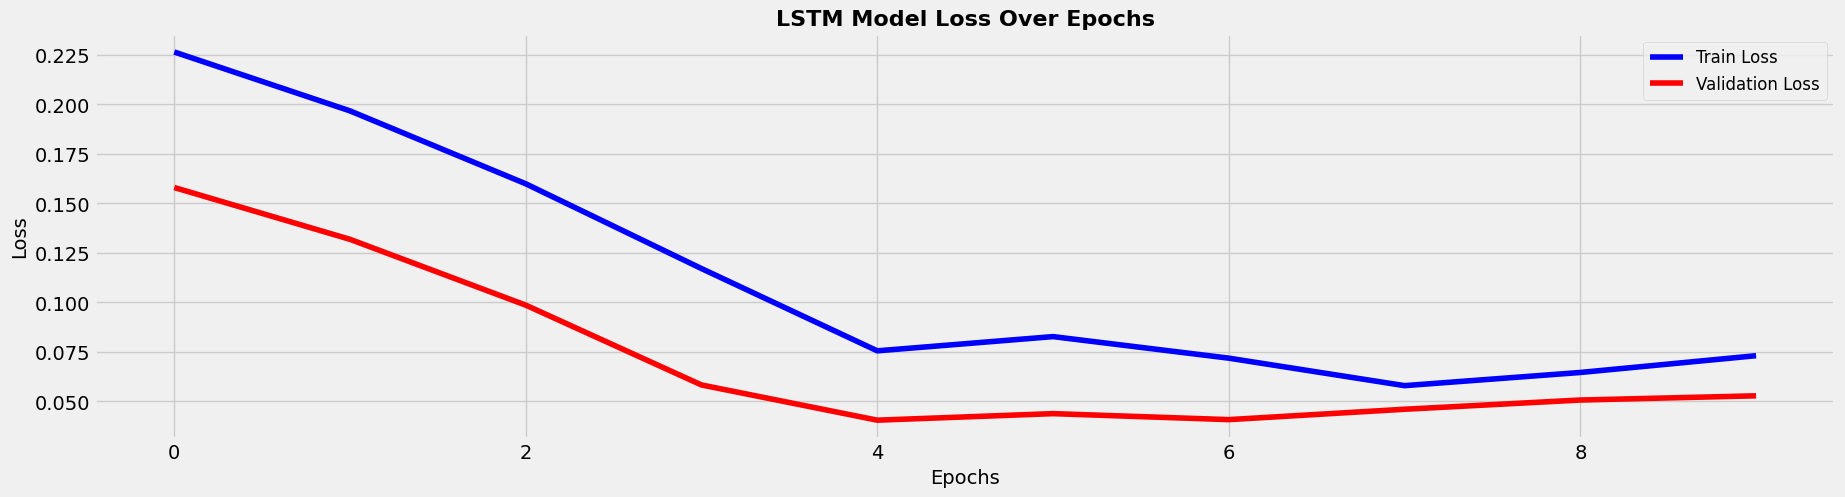

In [94]:
# --- Plot Loss ---
plt.figure(figsize=(20,5))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('LSTM Model Loss Over Epochs', fontsize=16, fontweight='bold')
plt.ylabel('Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)
plt.show()


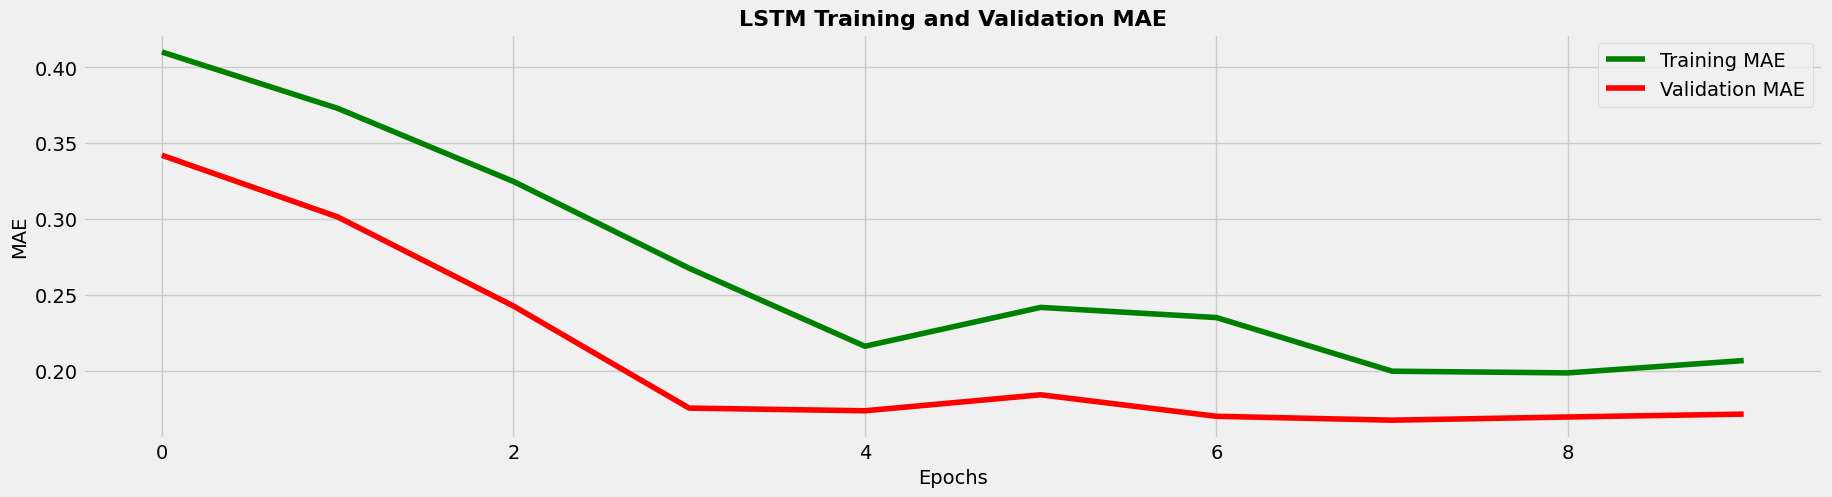

In [95]:
# --- Plot MAE ---
plt.figure(figsize=(20,5))
plt.plot(history.history['mae'], 'g-', label='Training MAE')
plt.plot(history.history['val_mae'], 'r-', label='Validation MAE')
plt.title('LSTM Training and Validation MAE', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('MAE', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

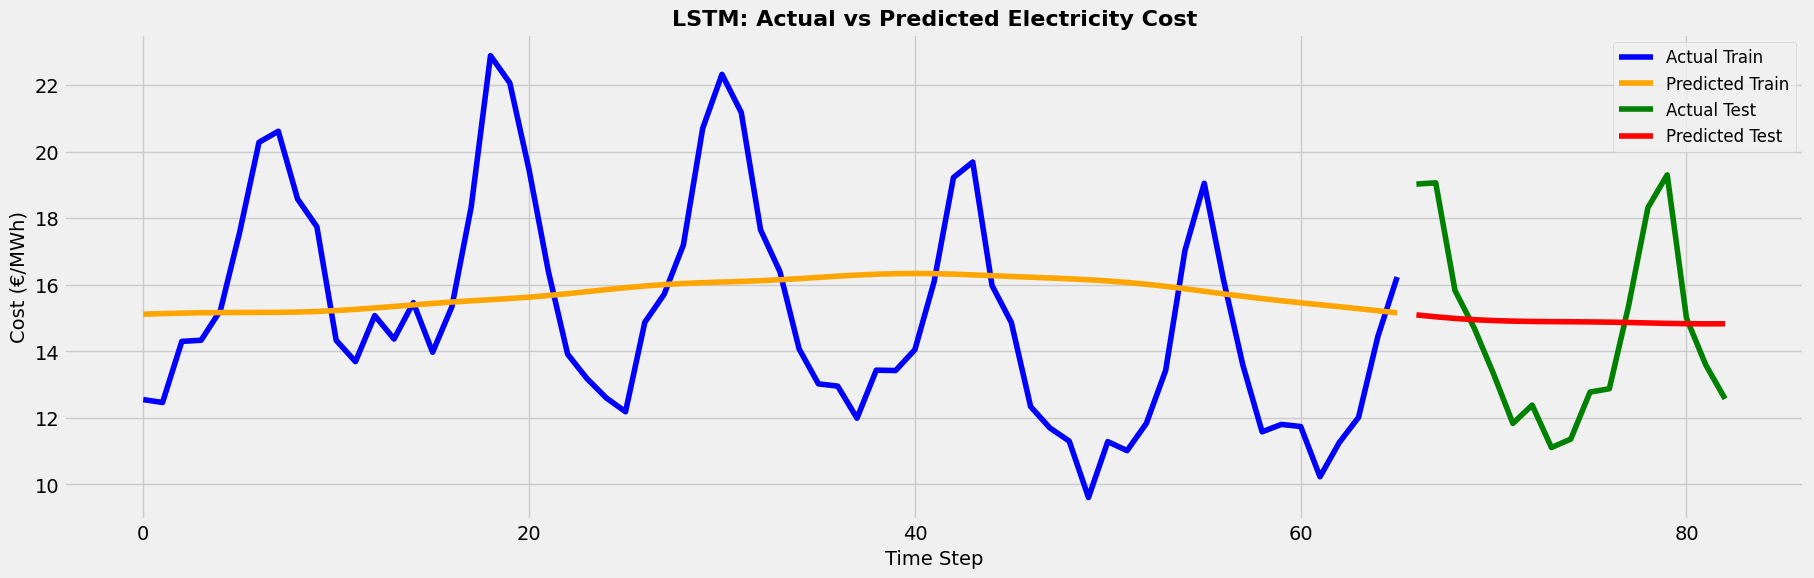

In [96]:
plt.figure(figsize=(20,6))

# Plot training set
plt.plot(y_train_inv, label='Actual Train', color='blue')
plt.plot(train_predict_inv, label='Predicted Train', color='orange')

# Plot test set
plt.plot(np.arange(len(y_train_inv), len(y_train_inv)+len(y_test_inv)), y_test_inv, label='Actual Test', color='green')
plt.plot(np.arange(len(y_train_inv), len(y_train_inv)+len(y_test_inv)), test_predict_inv, label='Predicted Test', color='red')

plt.title('LSTM: Actual vs Predicted Electricity Cost', fontsize=16, fontweight='bold')
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Cost (€/MWh)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


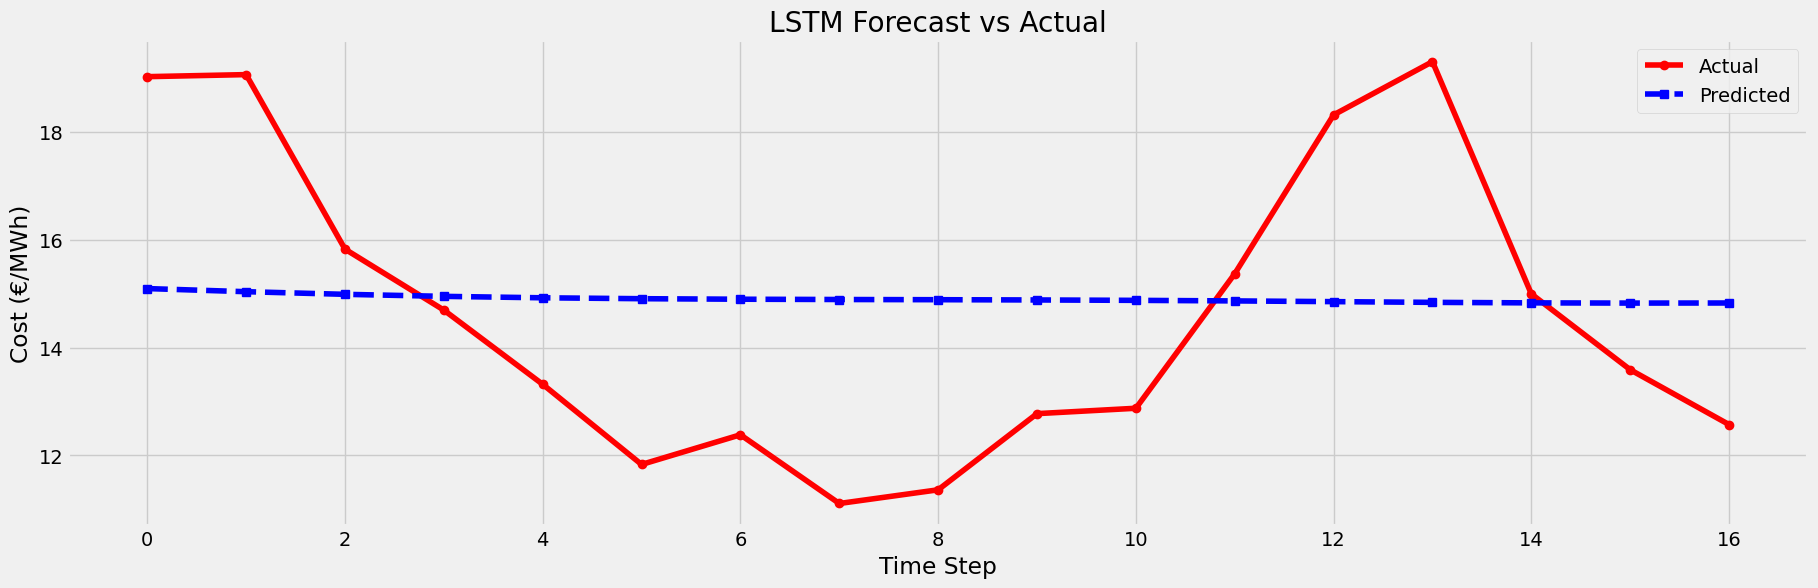

In [97]:
# =========================
#  Plot results
# =========================
plt.figure(figsize=(20,6))
plt.plot(y_test_inv1[:200], label='Actual', color='red', marker='o')
plt.plot(test_predict_inv1[:200], label='Predicted', color='blue', linestyle='--', marker='s')
plt.title('LSTM Forecast vs Actual')
plt.xlabel('Time Step')
plt.ylabel('Cost (€/MWh)')
plt.legend()
plt.grid(True)
plt.show()